#  Data preproseiing

# ---------------------------------------------------------------------------------------------------------------------------

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

# 경로 설정
data_dir = "/Users/taehokim/lab/BRL_AI/data"
sanitation_path = os.path.join(data_dir, 'Sanitation.xlsx')

# 소재방 불러오기
material_path = os.path.join(data_dir, 'Material.xlsx')


In [2]:
import pandas as pd

# microbial (Sheet0)
data_s0 = pd.read_excel(sanitation_path, sheet_name=0, skiprows=2, usecols="B:D")

# taxonomic
data_s1 = pd.read_excel(sanitation_path, sheet_name=1, skiprows=2, usecols='B:AI')  # phylum
data_s2 = pd.read_excel(sanitation_path, sheet_name=2, skiprows=2, usecols='B:BM')  # class
data_s3 = pd.read_excel(sanitation_path, sheet_name=3, skiprows=2, usecols='B:ET')  # order
data_s4 = pd.read_excel(sanitation_path, sheet_name=4, skiprows=2, usecols='B:JV')  # family
data_s5 = pd.read_excel(sanitation_path, sheet_name=5, skiprows=2, usecols='B:WL')  # genus

# 첫 번째 컬럼(Description 등)은 접두사 붙이지 않음
data_s1.columns = [data_s1.columns[0]] + ['p__' + col for col in data_s1.columns[1:]]
data_s2.columns = [data_s2.columns[0]] + ['c__' + col for col in data_s2.columns[1:]]
data_s3.columns = [data_s3.columns[0]] + ['o__' + col for col in data_s3.columns[1:]]
data_s4.columns = [data_s4.columns[0]] + ['f__' + col for col in data_s4.columns[1:]]
data_s5.columns = [data_s5.columns[0]] + ['g__' + col for col in data_s5.columns[1:]]

# 확인
print(data_s1.columns[:5])
print(data_s2.columns[:5])
print(data_s3.columns[:5])
print(data_s4.columns[:5])
print(data_s5.columns[:5])

Index(['Description', 'p__Firmicutes', 'p__Actinobacteriota',
       'p__Bacteroidota', 'p__Chloroflexi'],
      dtype='object')
Index(['Description', 'c__Bacilli', 'c__Actinobacteria', 'c__Bacteroidia',
       'c__Chloroflexia'],
      dtype='object')
Index(['Description', 'o__Lactobacillales', 'o__Corynebacteriales',
       'o__Flavobacteriales', 'o__Thermomicrobiales'],
      dtype='object')
Index(['Description', 'f__Leuconostocaceae', 'f__Corynebacteriaceae',
       'f__Streptococcaceae', 'f__Weeksellaceae'],
      dtype='object')
Index(['Description', 'g__Leuconostoc', 'g__Corynebacterium', 'g__Lactococcus',
       'g__Chryseobacterium'],
      dtype='object')


# 전처리 순서 변경

## 1. 시퀀싱 탈락 및 이상시료 Sample 대체 

In [3]:
import re
import numpy as np
from IPython.display import display

# 시퀀싱 탈락 시료 (하드코딩)
fail_samples = ["A5-22", "A7-4", "A7-16", "A7-28"]

def extract_day(description):
    m = re.match(r'A(\d+)-\d+', str(description))
    return int(m.group(1)) if m else np.nan

# taxonomy level 데이터 리스트 생성
taxonomic_dfs = [
    ("Phylum", data_s1),
    ("Class", data_s2),
    ("Order", data_s3),
    ("Family", data_s4),
    ("Genus", data_s5)
]

# 전처리 결과 저장용 딕셔너리
preprocess_summary = {}
imputed_taxonomic_levels = []

for level_name, df in taxonomic_dfs:
    df_new = df.copy()
    feature_cols = [col for col in df_new.columns if col != 'Description']
    df_new['Day'] = df_new['Description'].apply(extract_day)
    
    # 1. 시퀀싱 탈락 시료 확인
    fail_mask = df_new['Description'].isin(fail_samples)
    actual_fail_samples = df_new.loc[fail_mask, 'Description'].tolist()
    
    # 2. 하나만 검출된 시료 찾기
    only_100_mask = ((df_new[feature_cols] == 100).sum(axis=1) == 1) & \
                    ((df_new[feature_cols] != 0).sum(axis=1) == 1)
    only_100_samples = df_new.loc[only_100_mask, 'Description'].tolist()
    
    # 3. 하나만 검출된 샘플의 100 값을 0으로 대체
    for idx in df_new[only_100_mask].index:
        df_new.loc[idx, feature_cols] = 0
    
    # 전체 대체 대상 샘플 리스트
    all_replaced_samples = actual_fail_samples + only_100_samples
    
    # 4-5. Day별로 그룹화하여 대체 샘플들을 해당 Day의 평균으로 대체
    all_replaced_mask = df_new['Description'].isin(all_replaced_samples)
    for idx in df_new[all_replaced_mask].index:
        day = df_new.loc[idx, 'Day']
        day_mask = (df_new['Day'] == day) & (~df_new['Description'].isin(all_replaced_samples))
        day_df = df_new.loc[day_mask, feature_cols]
        if len(day_df) > 0:
            mean_vals = day_df.mean()
            fill_vals = mean_vals.fillna(0)
            df_new.loc[idx, feature_cols] = fill_vals.values
        else:
            df_new.loc[idx, feature_cols] = 0
    
    # 모든 샘플에 대해 feature 합이 100이 되도록 정규화
    for idx in df_new.index:
        total = df_new.loc[idx, feature_cols].sum()
        if total > 0:
            df_new.loc[idx, feature_cols] = df_new.loc[idx, feature_cols] / total * 100
        else:
            df_new.loc[idx, feature_cols] = 0
    
    # Day 컬럼 제거
    df_new = df_new.drop(columns=['Day'])
    imputed_taxonomic_levels.append((level_name, df_new))
    
    # level별 요약 정보 저장
    preprocess_summary[level_name] = {
        "fail_samples": actual_fail_samples,
        "only_100_samples": only_100_samples,
        "all_replaced_samples": all_replaced_samples,
        "num_fail_samples": len(actual_fail_samples),
        "num_only_100_samples": len(only_100_samples),
        "num_all_replaced_samples": len(all_replaced_samples),
        "shape": df_new.shape,
        "feature_cols": feature_cols
    }
    print(f"[{level_name}] shape: {df_new.shape[0]} rows x {df_new.shape[1]} columns")

# 대체된 샘플 정보 출력 및 Level별로 3개씩 display
for level_name, df in imputed_taxonomic_levels:
    info = preprocess_summary[level_name]
    all_replaced_samples = info["all_replaced_samples"]
    actual_fail_samples = info["fail_samples"]
    only_100_samples = info["only_100_samples"]
    feature_cols = info["feature_cols"]
    
    if all_replaced_samples:
        print(f"\n[{level_name}] 대체된 Sample 정보:")
        print(f"  - 시퀀싱 탈락 시료: {info['num_fail_samples']}개 → {actual_fail_samples}")
        print(f"  - 하나만 검출된 시료: {info['num_only_100_samples']}개 → {only_100_samples}")
        print(f"  - 총 대체 샘플: {info['num_all_replaced_samples']}개")
        
        df_replaced = df[df['Description'].isin(all_replaced_samples)].set_index('Description')
        display_samples = df_replaced.head(3)
        print(f"\n대체된 Sample 데이터 (상위 3개 표시, 전체: {info['num_all_replaced_samples']}개)")
        display(display_samples)
        
        if only_100_samples:
            print("\n하나만 검출된 시료의 원본 100 Feature 정보 (상위 3개):")
            display_only_100 = only_100_samples[:3]
            for desc in display_only_100:
                orig_row = df[df['Description'] == desc]
                if not orig_row.empty:
                    feat_100 = [col for col in feature_cols if orig_row.iloc[0][col] == 100]
                    print(f"  - {desc}: 100이었던 feature → {', '.join(feat_100) if feat_100 else '없음'}")
        
        sums_display = display_samples.sum(axis=1)
        print(f"\n각 대체 샘플의 feature 합계 (상위 3개): {sums_display.values}")
        all_sums = df_replaced.sum(axis=1)
        print(f"전체 대체 샘플 합계 통계: 평균={all_sums.mean():.2f}, 최소={all_sums.min():.2f}, 최대={all_sums.max():.2f}")
        
        replaced_df_with_day = df[df['Description'].isin(all_replaced_samples)].copy()
        replaced_df_with_day['Day'] = replaced_df_with_day['Description'].apply(extract_day)
        day_distribution = replaced_df_with_day.groupby('Day').size()
        print(f"\nDay별 대체 샘플 분포:")
        for day, count in day_distribution.items():
            day_fail = len([s for s in actual_fail_samples if extract_day(s) == day])
            day_100 = len([s for s in only_100_samples if extract_day(s) == day])
            print(f"  Day {day}: {count}개 (시퀀싱 탈락: {day_fail}개, 하나만 검출: {day_100}개)")
    else:
        print(f"\n[{level_name}] 대체된 샘플 없음")

print("\n=== 정규화 확인: 전체 샘플의 feature 합계 통계 ===")
for level_name, df in imputed_taxonomic_levels:
    feature_cols = preprocess_summary[level_name]["feature_cols"]
    all_sums = df[feature_cols].sum(axis=1)
    print(f"[{level_name}] 전체 샘플 합계 - 평균: {all_sums.mean():.2f}, 최소: {all_sums.min():.2f}, 최대: {all_sums.max():.2f}")

# level별 전처리 요약 딕셔너리(preprocess_summary)로 전체 정보 관리

[Phylum] shape: 270 rows x 34 columns
[Class] shape: 270 rows x 64 columns
[Order] shape: 270 rows x 149 columns
[Family] shape: 270 rows x 281 columns
[Genus] shape: 270 rows x 609 columns

[Phylum] 대체된 Sample 정보:
  - 시퀀싱 탈락 시료: 4개 → ['A5-22', 'A7-4', 'A7-16', 'A7-28']
  - 하나만 검출된 시료: 7개 → ['A0-20', 'A1-11', 'A1-26', 'A3-20', 'A5-10', 'A9-10', 'A9-22']
  - 총 대체 샘플: 11개

대체된 Sample 데이터 (상위 3개 표시, 전체: 11개)


,p__Firmicutes,p__Actinobacteriota,p__Bacteroidota,p__Chloroflexi,p__Proteobacteria,p__Unassigned,p__Cyanobacteria,p__Deinococcota,p__Bacteria(d),p__Bdellovibrionota,...,p__Spirochaetota,p__Synergistota,p__Hydrogenedentes,p__Halobacterota,p__WPS-2,p__Halanaerobiaeota,p__Dependentiae,p__Fibrobacterota,p__Nanoarchaeota,p__Euryarchaeota
Description,,,,,,,,,,,,,,,,,,,,,
A0-20,49.328620,2.122783,1.671567,0.002769,46.522145,0.084124,0.012081,0.212211,0.001119,0.018720,...,0.0,0.0,0.0,0.00797,0.0,0.001335,0.0,0.0,0.0,0.0
A1-11,52.829216,0.875911,1.156914,0.000000,44.513064,0.159822,0.000000,0.292766,0.010046,0.026962,...,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0
A1-26,52.829216,0.875911,1.156914,0.000000,44.513064,0.159822,0.000000,0.292766,0.010046,0.026962,...,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0



하나만 검출된 시료의 원본 100 Feature 정보 (상위 3개):
  - A0-20: 100이었던 feature → 없음
  - A1-11: 100이었던 feature → 없음
  - A1-26: 100이었던 feature → 없음

각 대체 샘플의 feature 합계 (상위 3개): [100. 100. 100.]
전체 대체 샘플 합계 통계: 평균=100.00, 최소=100.00, 최대=100.00

Day별 대체 샘플 분포:
  Day 0: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 1: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)
  Day 3: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 5: 2개 (시퀀싱 탈락: 1개, 하나만 검출: 1개)
  Day 7: 3개 (시퀀싱 탈락: 3개, 하나만 검출: 0개)
  Day 9: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)

[Class] 대체된 Sample 정보:
  - 시퀀싱 탈락 시료: 4개 → ['A5-22', 'A7-4', 'A7-16', 'A7-28']
  - 하나만 검출된 시료: 7개 → ['A0-20', 'A1-11', 'A1-26', 'A3-20', 'A5-10', 'A9-10', 'A9-22']
  - 총 대체 샘플: 11개

대체된 Sample 데이터 (상위 3개 표시, 전체: 11개)


,c__Bacilli,c__Actinobacteria,c__Bacteroidia,c__Chloroflexia,c__Gammaproteobacteria,c__Unassigned,c__Coriobacteriia,c__Proteobacteria(p),c__Alphaproteobacteria,c__Sericytochromatia,...,c__Thermoanaerobacteria,c__Halanaerobiia,c__Planctomycetota_OM190,c__Babeliae,c__Fibrobacteria,c__Nanoarchaeia,c__Methanobacteria,c__Oligoflexia,c__Ignavibacteria,c__Fimbriimonadia
Description,,,,,,,,,,,,,,,,,,,,,
A0-20,49.117792,2.120496,1.671567,0.002769,45.675915,0.084124,0.000634,0.00000,0.846230,0.000941,...,0.000000,0.001335,0.000000,0.0,0.0,0.0,0.0,0.000402,0.0,0.0
A1-11,52.729329,0.871804,1.156914,0.000000,41.206082,0.159822,0.001039,0.00042,3.306563,0.000000,...,0.005476,0.000000,0.000839,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
A1-26,52.729329,0.871804,1.156914,0.000000,41.206082,0.159822,0.001039,0.00042,3.306563,0.000000,...,0.005476,0.000000,0.000839,0.0,0.0,0.0,0.0,0.000000,0.0,0.0



하나만 검출된 시료의 원본 100 Feature 정보 (상위 3개):
  - A0-20: 100이었던 feature → 없음
  - A1-11: 100이었던 feature → 없음
  - A1-26: 100이었던 feature → 없음

각 대체 샘플의 feature 합계 (상위 3개): [100. 100. 100.]
전체 대체 샘플 합계 통계: 평균=100.00, 최소=100.00, 최대=100.00

Day별 대체 샘플 분포:
  Day 0: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 1: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)
  Day 3: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 5: 2개 (시퀀싱 탈락: 1개, 하나만 검출: 1개)
  Day 7: 3개 (시퀀싱 탈락: 3개, 하나만 검출: 0개)
  Day 9: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)

[Order] 대체된 Sample 정보:
  - 시퀀싱 탈락 시료: 4개 → ['A5-22', 'A7-4', 'A7-16', 'A7-28']
  - 하나만 검출된 시료: 7개 → ['A0-20', 'A1-11', 'A1-26', 'A3-20', 'A5-10', 'A9-10', 'A9-22']
  - 총 대체 샘플: 11개

대체된 Sample 데이터 (상위 3개 표시, 전체: 11개)


...


하나만 검출된 시료의 원본 100 Feature 정보 (상위 3개):
  - A0-20: 100이었던 feature → 없음
  - A1-11: 100이었던 feature → 없음
  - A1-26: 100이었던 feature → 없음

각 대체 샘플의 feature 합계 (상위 3개): [100. 100. 100.]
전체 대체 샘플 합계 통계: 평균=100.00, 최소=100.00, 최대=100.00

Day별 대체 샘플 분포:
  Day 0: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 1: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)
  Day 3: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 5: 2개 (시퀀싱 탈락: 1개, 하나만 검출: 1개)
  Day 7: 3개 (시퀀싱 탈락: 3개, 하나만 검출: 0개)
  Day 9: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)

[Family] 대체된 Sample 정보:
  - 시퀀싱 탈락 시료: 4개 → ['A5-22', 'A7-4', 'A7-16', 'A7-28']
  - 하나만 검출된 시료: 7개 → ['A0-20', 'A1-11', 'A1-26', 'A3-20', 'A5-10', 'A9-10', 'A9-22']
  - 총 대체 샘플: 11개

대체된 Sample 데이터 (상위 3개 표시, 전체: 11개)


,f__Leuconostocaceae,f__Corynebacteriaceae,f__Streptococcaceae,f__Weeksellaceae,f__Thermomicrobiales_JG30-KF-CM45,f__Moraxellaceae,f__Unassigned,f__Lactobacillaceae,f__Atopobiaceae,f__Bacilli(c),...,f__Ignavibacteriaceae,f__Dermatophilaceae,f__Fimbriimonadaceae,f__Planctomycetales(o),f__Ardenticatenales(o),f__Halococcaceae,f__Pedosphaeraceae,f__Kallotenuales_AKIW781,f__Alcanivoracaceae1,f__Ignavibacteriales_PHOS-HE36
Description,,,,,,,,,,,,,,,,,,,,,
A0-20,8.492776,0.166404,23.666539,1.280345,0.002769,9.331097,0.084124,1.325527,0.000000,0.018814,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
A1-11,3.685015,0.201598,35.231952,0.421981,0.000000,4.561179,0.159822,0.549222,0.001039,0.062810,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000839,0.0
A1-26,3.685015,0.201598,35.231952,0.421981,0.000000,4.561179,0.159822,0.549222,0.001039,0.062810,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000839,0.0



하나만 검출된 시료의 원본 100 Feature 정보 (상위 3개):
  - A0-20: 100이었던 feature → 없음
  - A1-11: 100이었던 feature → 없음
  - A1-26: 100이었던 feature → 없음

각 대체 샘플의 feature 합계 (상위 3개): [100. 100. 100.]
전체 대체 샘플 합계 통계: 평균=100.00, 최소=100.00, 최대=100.00

Day별 대체 샘플 분포:
  Day 0: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 1: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)
  Day 3: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 5: 2개 (시퀀싱 탈락: 1개, 하나만 검출: 1개)
  Day 7: 3개 (시퀀싱 탈락: 3개, 하나만 검출: 0개)
  Day 9: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)

[Genus] 대체된 Sample 정보:
  - 시퀀싱 탈락 시료: 4개 → ['A5-22', 'A7-4', 'A7-16', 'A7-28']
  - 하나만 검출된 시료: 7개 → ['A0-20', 'A1-11', 'A1-26', 'A3-20', 'A5-10', 'A9-10', 'A9-22']
  - 총 대체 샘플: 11개

대체된 Sample 데이터 (상위 3개 표시, 전체: 11개)


,g__Leuconostoc,g__Corynebacterium,g__Lactococcus,g__Chryseobacterium,g__Thermomicrobiales_JG30-KF-CM45,g__Acinetobacter,g__Unassigned,g__Lactobacillus,g__Atopobiaceae(f),g__Bacilli(c),...,g__Kallotenuales_AKIW781,g__Alcanivorax,g__Ignavibacteriales_PHOS-HE36,g__Tissierella,g__Atopostipes,g__Terribacillus,g__Pantoea,g__Chroococcidiopsaceae(f).1,g__Seinonella,g__Thermoclostridium
Description,,,,,,,,,,,,,,,,,,,,,
A0-20,7.992581,0.152968,21.781376,0.624120,0.002769,6.672528,0.084124,1.290214,0.000000,0.018814,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000
A1-11,3.171172,0.196317,32.954487,0.140337,0.000000,3.270603,0.159822,0.496538,0.001039,0.062810,...,0.0,0.000839,0.0,0.0,0.0,0.0,0.007436,0.0,0.0,0.00478
A1-26,3.171172,0.196317,32.954487,0.140337,0.000000,3.270603,0.159822,0.496538,0.001039,0.062810,...,0.0,0.000839,0.0,0.0,0.0,0.0,0.007436,0.0,0.0,0.00478



하나만 검출된 시료의 원본 100 Feature 정보 (상위 3개):
  - A0-20: 100이었던 feature → 없음
  - A1-11: 100이었던 feature → 없음
  - A1-26: 100이었던 feature → 없음

각 대체 샘플의 feature 합계 (상위 3개): [100. 100. 100.]
전체 대체 샘플 합계 통계: 평균=100.00, 최소=100.00, 최대=100.00

Day별 대체 샘플 분포:
  Day 0: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 1: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)
  Day 3: 1개 (시퀀싱 탈락: 0개, 하나만 검출: 1개)
  Day 5: 2개 (시퀀싱 탈락: 1개, 하나만 검출: 1개)
  Day 7: 3개 (시퀀싱 탈락: 3개, 하나만 검출: 0개)
  Day 9: 2개 (시퀀싱 탈락: 0개, 하나만 검출: 2개)

=== 정규화 확인: 전체 샘플의 feature 합계 통계 ===
[Phylum] 전체 샘플 합계 - 평균: 100.00, 최소: 100.00, 최대: 100.00
[Class] 전체 샘플 합계 - 평균: 100.00, 최소: 100.00, 최대: 100.00
[Order] 전체 샘플 합계 - 평균: 100.00, 최소: 100.00, 최대: 100.00
[Family] 전체 샘플 합계 - 평균: 100.00, 최소: 100.00, 최대: 100.00
[Genus] 전체 샘플 합계 - 평균: 100.00, 최소: 100.00, 최대: 100.00


## 2. Pseuduo Count 대압

In [4]:
import numpy as np

# CLR 변환 전 0값을 pseudo count(1e-6)로 대체
pseudo_count = 1e-6
clr_ready_taxonomic_levels = []

for level_name, df in imputed_taxonomic_levels:
    df_clr = df.copy()
    feature_cols = [col for col in df_clr.columns if col != 'Description']
    # 0값을 pseudo count로 대체
    df_clr[feature_cols] = df_clr[feature_cols].replace(0, pseudo_count)
    clr_ready_taxonomic_levels.append((level_name, df_clr))
    print(f"[{level_name}] 0값을 pseudo count({pseudo_count})로 대체 완료 (shape: {df_clr.shape})")

# 이후 clr_ready_taxonomic_levels에서 CLR 변환 진행하면 오류 없이 처리됩니다.

[Phylum] 0값을 pseudo count(1e-06)로 대체 완료 (shape: (270, 34))
[Class] 0값을 pseudo count(1e-06)로 대체 완료 (shape: (270, 64))
[Order] 0값을 pseudo count(1e-06)로 대체 완료 (shape: (270, 149))
[Family] 0값을 pseudo count(1e-06)로 대체 완료 (shape: (270, 281))
[Genus] 0값을 pseudo count(1e-06)로 대체 완료 (shape: (270, 609))


## 3. CLR 변환

In [5]:
import numpy as np
import pandas as pd

# 1. CLR 변환 수행 (pseudo count는 이미 대입됨)
clr_transformed_taxonomic_levels = []

print("\n=== CLR 변환 수행 ===")

for level_name, df in clr_ready_taxonomic_levels:
    df_clr = df.copy()
    feature_cols = [col for col in df_clr.columns if col != 'Description']

    print(f"\n[{level_name}] CLR 변환 중...")

    # CLR 변환 (벡터화)
    X = df_clr[feature_cols].values.astype(np.float64)
    log_X = np.log(X)
    gm = log_X.mean(axis=1).reshape(-1, 1)
    clr_X = log_X - gm
    df_clr[feature_cols] = clr_X

    # 합이 0에 가까운지 확인
    row_sums = df_clr[feature_cols].sum(axis=1)
    finite_sums = row_sums[np.isfinite(row_sums)]
    print(f"  각 샘플의 CLR 값 합계 범위: {finite_sums.min():.6f} ~ {finite_sums.max():.6f} (0에 가까워야 함)")

    clr_transformed_taxonomic_levels.append((level_name, df_clr))
    print(f"  변환 완료: {df_clr.shape[0]} samples × {len(feature_cols)} features")
    clr_min = np.nanmin(df_clr[feature_cols].values)
    clr_max = np.nanmax(df_clr[feature_cols].values)
    print(f"  CLR 값 범위: {clr_min:.3f} ~ {clr_max:.3f}")

print("\n=== CLR 변환 결과 요약 ===")
for level_name, df_clr in clr_transformed_taxonomic_levels:
    feature_cols = [col for col in df_clr.columns if col != 'Description']
    print(f"\n[{level_name}]")
    print(f"  📊 샘플 수: {len(df_clr)}")
    print(f"  🧬 Feature 수: {len(feature_cols)}")
    feature_means = df_clr[feature_cols].mean()
    feature_stds = df_clr[feature_cols].std()
    valid_means = feature_means.dropna()
    valid_stds = feature_stds.dropna()
    if len(valid_means) > 0:
        print(f"  📈 CLR 값 범위: {df_clr[feature_cols].min().min():.3f} ~ {df_clr[feature_cols].max().max():.3f}")
        print(f"  📊 Feature 평균값 범위: {valid_means.min():.3f} ~ {valid_means.max():.3f}")
        print(f"  📊 Feature 표준편차 범위: {valid_stds.min():.3f} ~ {valid_stds.max():.3f}")
        print(f"  📝 상위 5개 Feature CLR 값 예시:")
        for i, feat in enumerate(feature_cols[:5]):
            if feat in valid_means.index and feat in valid_stds.index:
                mean_val = valid_means[feat]
                std_val = valid_stds[feat]
                print(f"    {feat}: 평균={mean_val:.3f}, 표준편차={std_val:.3f}")
    else:
        print(f"  ⚠️ 유효한 CLR 값이 없습니다.")

print("\n✅ CLR 변환 완료!")
print("CLR 변환된 데이터는 'clr_transformed_taxonomic_levels' 변수에 저장되었습니다.")

# 3. CLR 변환 전후 비교 (첫 번째 레벨 예시)
if clr_transformed_taxonomic_levels:
    level_name, df_clr = clr_transformed_taxonomic_levels[0]
    level_name_orig, df_orig = clr_ready_taxonomic_levels[0]
    feature_cols = [col for col in df_clr.columns if col != 'Description']

    print(f"\n=== CLR 변환 전후 비교 ({level_name}) ===")
    print("상위 3개 샘플, 상위 5개 Feature:")

    orig_sample = df_orig[['Description'] + feature_cols[:5]].head(3)
    print(f"\n📋 변환 전 (pseudo count 적용):")
    print(orig_sample.to_string(index=False))

    clr_sample = df_clr[['Description'] + feature_cols[:5]].head(3)
    print(f"\n🔄 변환 후 (CLR):")
    print(clr_sample.to_string(index=False))


=== CLR 변환 수행 ===

[Phylum] CLR 변환 중...
  각 샘플의 CLR 값 합계 범위: -0.000000 ~ 0.000000 (0에 가까워야 함)
  변환 완료: 270 samples × 33 features
  CLR 값 범위: -6.929 ~ 17.155

[Class] CLR 변환 중...
  각 샘플의 CLR 값 합계 범위: -0.000000 ~ 0.000000 (0에 가까워야 함)
  변환 완료: 270 samples × 63 features
  CLR 값 범위: -4.524 ~ 17.660

[Order] CLR 변환 중...
  각 샘플의 CLR 값 합계 범위: -0.000000 ~ -0.000000 (0에 가까워야 함)
  변환 완료: 270 samples × 148 features
  CLR 값 범위: -5.427 ~ 17.838

[Family] CLR 변환 중...
  각 샘플의 CLR 값 합계 범위: -0.000000 ~ 0.000000 (0에 가까워야 함)
  변환 완료: 270 samples × 280 features
  CLR 값 범위: -5.067 ~ 17.719

[Genus] CLR 변환 중...
  각 샘플의 CLR 값 합계 범위: 0.000000 ~ 0.000000 (0에 가까워야 함)
  변환 완료: 270 samples × 608 features
  CLR 값 범위: -4.108 ~ 17.925

=== CLR 변환 결과 요약 ===

[Phylum]
  📊 샘플 수: 270
  🧬 Feature 수: 33
  📈 CLR 값 범위: -6.929 ~ 17.155
  📊 Feature 평균값 범위: -2.451 ~ 15.176
  📊 Feature 표준편차 범위: 0.968 ~ 5.658
  📝 상위 5개 Feature CLR 값 예시:
    p__Firmicutes: 평균=15.138, 표준편차=1.066
    p__Actinobacteriota: 평균=10.718, 표준편차=2.433
    p

## 4. 'Ubassigebd 제거

In [6]:
# 각 level별 'Unassigned' Feature 제거 (p__/c__/o__/f__/g__Unassigned)
taxonomic_dfs = [
    ("Phylum", data_s1),
    ("Class", data_s2),
    ("Order", data_s3),
    ("Family", data_s4),
    ("Genus", data_s5)
]

removed_unassigned_taxonomic_levels = []
for level_name, df in clr_transformed_taxonomic_levels:
    df_new = df.copy()
    prefix = {
        "Phylum": "p__",
        "Class": "c__",
        "Order": "o__",
        "Family": "f__",
        "Genus": "g__"
    }.get(level_name, "")
    unassigned_col = prefix + "Unassigned"
    before_shape = df_new.shape
    if unassigned_col in df_new.columns:
        df_new = df_new.drop(columns=[unassigned_col])
        print(f"[{level_name}] '{unassigned_col}' Feature 제거, shape: {before_shape} → {df_new.shape}")

    removed_unassigned_taxonomic_levels.append((level_name, df_new))

[Phylum] 'p__Unassigned' Feature 제거, shape: (270, 34) → (270, 33)
[Class] 'c__Unassigned' Feature 제거, shape: (270, 64) → (270, 63)
[Order] 'o__Unassigned' Feature 제거, shape: (270, 149) → (270, 148)
[Family] 'f__Unassigned' Feature 제거, shape: (270, 281) → (270, 280)
[Genus] 'g__Unassigned' Feature 제거, shape: (270, 609) → (270, 608)


## 5. 희귀 Feature Filtering 
- Pseudo Count가 존재하므로 0이 없어 0 대신 Pseudo Count 기반, feature 필터링

In [7]:
import numpy as np
import pandas as pd
import re

def extract_day(description):
    m = re.match(r'A(\d+)-\d+', str(description))
    return int(m.group(1)) if m else np.nan

# removed_unassigned_taxonomic_levels에서 희귀 feature 제거 (1e-6 기준)
rare_feature_filtered_taxonomic_levels = []

for level_name, df in removed_unassigned_taxonomic_levels:
    df = df.copy()
    df['Day'] = df['Description'].apply(extract_day)
    feature_cols = [col for col in df.columns if col not in ['Description', 'Day']]
    selected_features = []
    for feat in feature_cols:
        before_mask = df['Day'] < 9
        before_nonzero_ratio = (df.loc[before_mask, feat] > 1e-6).sum() / before_mask.sum() if before_mask.sum() > 0 else 0
        after_mask = df['Day'] >= 9
        after_nonzero_ratio = (df.loc[after_mask, feat] > 1e-6).sum() / after_mask.sum() if after_mask.sum() > 0 else 0
        # (1)과 (2)를 모두 만족해야 제거 (즉, 둘 다 10% 미만일 때만 제거)
        if not (before_nonzero_ratio < 0.1 and after_nonzero_ratio < 0.1):
            selected_features.append(feat)
    filtered_df = df[['Description'] + selected_features].copy()
    # 1e-6 기준, 결측치는 그대로 둠
    rare_feature_filtered_taxonomic_levels.append((level_name, filtered_df))
    print(f"[{level_name}] Day9 기준 양쪽 모두 1e-6 초과 값이 10% 미만인 feature만 제거 (남은 feature: {len(selected_features)})")

# rare_feature_filtered_taxonomic_levels에 결과가 저장됨

[Phylum] Day9 기준 양쪽 모두 1e-6 초과 값이 10% 미만인 feature만 제거 (남은 feature: 12)
[Class] Day9 기준 양쪽 모두 1e-6 초과 값이 10% 미만인 feature만 제거 (남은 feature: 13)
[Order] Day9 기준 양쪽 모두 1e-6 초과 값이 10% 미만인 feature만 제거 (남은 feature: 48)
[Family] Day9 기준 양쪽 모두 1e-6 초과 값이 10% 미만인 feature만 제거 (남은 feature: 85)
[Genus] Day9 기준 양쪽 모두 1e-6 초과 값이 10% 미만인 feature만 제거 (남은 feature: 133)


## 6. IQR 기반 Outlier 대체

In [8]:
import numpy as np
import pandas as pd

iqr_filtered_taxonomic_levels = []

for level_name, df in rare_feature_filtered_taxonomic_levels:
    feature_cols = [col for col in df.columns if col != 'Description']
    df = df.copy()
    df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(float)
    # 이상치 대체: Q1-1.5*IQR 미만은 Q1로, Q3+1.5*IQR 초과는 Q3로 대체
    for feat in feature_cols:
        for day, group in df.groupby("Day"):
            vals = group[feat].dropna()
            if len(vals) > 0:
                q1, q3 = np.percentile(vals, [25, 75])
                iqr = q3 - q1
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr
                idxs = group.index
                # Q1-1.5*IQR 미만은 Q1로, Q3+1.5*IQR 초과는 Q3로 대체
                df.loc[idxs, feat] = df.loc[idxs, feat].apply(
                    lambda x: q1 if x < lower else (q3 if x > upper else x)
                )
    # Day 컬럼 제거
    df = df.drop(columns=['Day'])
    iqr_filtered_taxonomic_levels.append((level_name, df))
    print(f"[{level_name}] Day별 IQR 기반 이상치(Q1-1.5*IQR/Q3+1.5*IQR) Q1/Q3로 대체 (shape: {df.shape[0]} rows x {df.shape[1]} columns)")

[Phylum] Day별 IQR 기반 이상치(Q1-1.5*IQR/Q3+1.5*IQR) Q1/Q3로 대체 (shape: 270 rows x 13 columns)
[Class] Day별 IQR 기반 이상치(Q1-1.5*IQR/Q3+1.5*IQR) Q1/Q3로 대체 (shape: 270 rows x 14 columns)
[Order] Day별 IQR 기반 이상치(Q1-1.5*IQR/Q3+1.5*IQR) Q1/Q3로 대체 (shape: 270 rows x 49 columns)
[Family] Day별 IQR 기반 이상치(Q1-1.5*IQR/Q3+1.5*IQR) Q1/Q3로 대체 (shape: 270 rows x 86 columns)
[Genus] Day별 IQR 기반 이상치(Q1-1.5*IQR/Q3+1.5*IQR) Q1/Q3로 대체 (shape: 270 rows x 134 columns)


In [9]:
import numpy as np
import pandas as pd
from IPython.display import display

# Day별로 각 feature의 평균값 계산
for level_name, df in iqr_filtered_taxonomic_levels:
    feature_cols = [col for col in df.columns if col != 'Description']
    df = df.copy()
    df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    # Day별 평균값 DataFrame 생성
    day_mean_df = df.groupby('Day')[feature_cols].mean().reset_index()
    print(f"\n[{level_name}] Day별 feature 평균값 (상위 5개 feature만 표시)")
    display(day_mean_df.iloc[:, :6].head(30))  # Day + 상위 5개 feature만 표시 (iloc로 Day 포함 6개 컬럼)


[Phylum] Day별 feature 평균값 (상위 5개 feature만 표시)


,Day,p__Firmicutes,p__Actinobacteriota,p__Bacteroidota,p__Chloroflexi,p__Proteobacteria
0,0,15.093525,11.412497,11.114939,-2.190936,15.054023
1,1,15.103519,10.525380,10.455016,-2.353586,15.234665
2,3,14.991994,10.928860,11.104044,-2.707896,14.644919
3,5,15.167564,10.896052,10.444021,-2.541544,14.930086
4,7,14.813732,11.515385,11.236845,-2.309901,15.345941
5,9,15.385598,10.911736,9.325882,-2.053814,15.658266
6,11,15.561476,11.707283,7.972332,-2.087288,15.538971
7,14,15.497749,11.080691,8.884728,-2.060375,15.757921
8,18,15.884383,11.415551,5.653365,-1.844928,15.738785



[Class] Day별 feature 평균값 (상위 5개 feature만 표시)


,Day,c__Bacilli,c__Actinobacteria,c__Bacteroidia,c__Chloroflexia,c__Gammaproteobacteria
0,0,15.928718,12.292966,11.998319,-1.446627,15.856686
1,1,15.875988,11.374041,11.329317,-1.512836,15.854970
2,3,15.907336,11.887311,12.100907,-1.805213,15.527545
3,5,16.082831,11.725965,11.487212,-1.610736,15.829175
4,7,15.734827,12.439639,12.170591,-1.476654,16.280204
5,9,16.166381,11.649080,10.195693,-1.376933,16.439426
6,11,16.425579,12.626394,8.896515,-1.201658,16.397630
7,14,16.244118,11.839974,9.675572,-1.292537,16.520184
8,18,16.596290,12.150140,6.387954,-1.139276,16.430078



[Order] Day별 feature 평균값 (상위 5개 feature만 표시)


,Day,o__Lactobacillales,o__Corynebacteriales,o__Flavobacteriales,o__Pseudomonadales,o__Bacilli(c)
0,0,15.182115,9.281157,11.192402,14.749828,-1.522966
1,1,15.224916,5.100054,7.276873,14.195255,1.902691
2,3,15.471977,9.212469,11.496826,14.340179,2.634481
3,5,15.672742,8.821666,10.758623,14.844278,4.121366
4,7,15.480527,9.782515,11.807939,15.695611,-1.617049
5,9,16.389441,5.083521,10.230679,16.475669,-1.090635
6,11,16.553656,4.969239,8.799811,16.408174,-1.046381
7,14,16.489059,3.037108,9.482725,16.552639,-1.079826
8,18,16.774152,3.078813,6.111505,16.406872,-0.916811



[Family] Day별 feature 평균값 (상위 5개 feature만 표시)


,Day,f__Leuconostocaceae,f__Corynebacteriaceae,f__Streptococcaceae,f__Weeksellaceae,f__Moraxellaceae
0,0,13.737048,5.796158,14.912927,11.382989,14.051964
1,1,12.719912,4.415987,15.010780,6.404500,13.093468
2,3,13.709479,5.467398,15.488586,11.058995,13.663428
3,5,13.194580,5.966514,15.365998,10.491522,14.424834
4,7,12.281481,4.381423,14.142809,11.375071,14.929693
5,9,7.169701,2.651916,12.364150,9.981528,16.017785
6,11,9.998305,-0.801941,12.977716,4.131010,15.643755
7,14,7.113973,1.824923,13.259859,6.494631,15.908905
8,18,10.872592,-0.906663,14.636022,2.336250,15.242807



[Genus] Day별 feature 평균값 (상위 5개 feature만 표시)


,Day,g__Leuconostoc,g__Corynebacterium,g__Lactococcus,g__Chryseobacterium,g__Acinetobacter
0,0,14.355345,5.649617,15.514378,11.515058,14.342980
1,1,13.391724,4.304082,15.697222,4.999140,13.342372
2,3,14.152416,5.725976,16.102215,11.074641,14.162854
3,5,13.556517,6.245042,15.959497,10.668488,14.912966
4,7,12.886036,5.040443,14.612832,11.315099,15.517775
5,9,7.599672,2.062214,12.823185,6.033874,16.421132
6,11,10.354511,-0.473686,13.369511,3.057420,16.107689
7,14,7.127887,-0.433583,13.739751,4.464236,16.342993
8,18,11.297946,-0.480360,15.123242,-0.453375,15.723211


## 7. 변화율 계산

In [10]:
import numpy as np
import pandas as pd
from IPython.display import display

# CLR 변환된 데이터에서 Day별 변화량 계산 (차이 기반)
print("=== CLR 변환 후 Day별 Feature 변화량 분석 ===")

# 변화량 분석 결과를 저장할 딕셔너리
change_analysis_results = {}

for level_name, df in iqr_filtered_taxonomic_levels:
    feature_cols = [col for col in df.columns if col != 'Description']
    df = df.copy()
    df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    day_mean_df = df.groupby('Day')[feature_cols].mean().reset_index()
    
    print(f"\n[{level_name}] Day별 CLR feature 변화량 (상위 10개 feature, 절댓값 기준 정렬)")
    
    # 각 feature별 변화량 계산
    feature_changes = []
    for feat in feature_cols:
        vals = day_mean_df[feat].values
        days = day_mean_df['Day'].values
        
        if len(vals) < 2 or np.all(np.isnan(vals)):
            continue
            
        # 최대값과 최소값 찾기
        min_idx = np.nanargmin(vals)
        max_idx = np.nanargmax(vals)
        min_val = vals[min_idx]
        max_val = vals[max_idx]
        min_day = days[min_idx]
        max_day = days[max_idx]
        
        # 변화량 계산 (CLR 변환된 데이터이므로 차이 계산)
        change_amount = max_val - min_val
        abs_change = abs(change_amount)
        
        # 증가/감소 패턴 확인
        if change_amount > 0:
            if min_day < max_day:
                trend = "증가"
                direction_str = f"Day{min_day}({min_val:.3f}) → Day{max_day}({max_val:.3f})"
            else:
                trend = "감소 후 증가"
                direction_str = f"Day{max_day}({max_val:.3f}) ← Day{min_day}({min_val:.3f})"
        else:
            if min_day > max_day:
                trend = "감소"
                direction_str = f"Day{max_day}({max_val:.3f}) → Day{min_day}({min_val:.3f})"
            else:
                trend = "증가 후 감소"
                direction_str = f"Day{min_day}({min_val:.3f}) ← Day{max_day}({max_val:.3f})"
        
        feature_changes.append({
            'feature': feat,
            'abs_change': abs_change,
            'change_amount': change_amount,
            'min_val': min_val,
            'max_val': max_val,
            'min_day': min_day,
            'max_day': max_day,
            'trend': trend,
            'direction_str': direction_str
        })
    
    # 절댓값 기준으로 정렬 (변화량이 큰 순서)
    feature_changes_sorted = sorted(feature_changes, key=lambda x: x['abs_change'], reverse=True)
    
    # 증가 패턴과 감소 패턴 분리 분석
    increase_features = [x for x in feature_changes_sorted if x['change_amount'] > 0]
    decrease_features = [x for x in feature_changes_sorted if x['change_amount'] < 0]
    
    # 결과를 딕셔너리에 저장
    change_analysis_results[level_name] = {
        'all_features': feature_changes_sorted,
        'top_10_features': feature_changes_sorted[:10],
        'increase_features': increase_features,
        'decrease_features': decrease_features,
        'day_mean_df': day_mean_df,
        'summary_stats': {
            'total_features': len(feature_changes_sorted),
            'increase_count': len(increase_features),
            'decrease_count': len(decrease_features),
            'max_increase': increase_features[0] if increase_features else None,
            'max_decrease': decrease_features[0] if decrease_features else None
        }
    }
    
    # 상위 10개 출력
    print(f"변화량 상위 10개 Feature:")
    for i, change_info in enumerate(feature_changes_sorted[:10]):
        feat = change_info['feature']
        abs_change = change_info['abs_change']
        change_amount = change_info['change_amount']
        trend = change_info['trend']
        direction_str = change_info['direction_str']
        
        print(f"  {i+1:2d}. {feat}")
        print(f"      변화량: {change_amount:+.3f} (절댓값: {abs_change:.3f})")
        print(f"      패턴: {trend} - {direction_str}")
    
    print(f"\n📈 증가 패턴 Feature: {len(increase_features)}개")
    if increase_features:
        print(f"   최대 증가: {increase_features[0]['feature']} (+{increase_features[0]['change_amount']:.3f})")
        print(f"   상위 3개: {[x['feature'] for x in increase_features[:3]]}")
    
    print(f"📉 감소 패턴 Feature: {len(decrease_features)}개")
    if decrease_features:
        print(f"   최대 감소: {decrease_features[0]['feature']} ({decrease_features[0]['change_amount']:.3f})")
        print(f"   상위 3개: {[x['feature'] for x in decrease_features[:3]]}")
    
    print("-" * 80)

print(f"\n✅ CLR 변환된 데이터의 변화량 분석 완료!")
print(f"💡 CLR 변환된 데이터에서는 차이(difference)가 비율 변화를 의미합니다.")
print(f"💡 양수는 상대적 증가, 음수는 상대적 감소를 나타냅니다.")

# 변화량 분석 결과 요약
print(f"\n=== 변화량 분석 결과 요약 ===")
for level_name, results in change_analysis_results.items():
    stats = results['summary_stats']
    print(f"[{level_name}]")
    print(f"  - 분석된 Feature 수: {stats['total_features']}")
    print(f"  - 증가 패턴: {stats['increase_count']}개")
    print(f"  - 감소 패턴: {stats['decrease_count']}개")
    if stats['max_increase']:
        print(f"  - 최대 증가 Feature: {stats['max_increase']['feature']} (+{stats['max_increase']['change_amount']:.3f})")
    if stats['max_decrease']:
        print(f"  - 최대 감소 Feature: {stats['max_decrease']['feature']} ({stats['max_decrease']['change_amount']:.3f})")

print(f"\n변화량 분석 결과는 'change_analysis_results' 변수에 저장되었습니다.")

=== CLR 변환 후 Day별 Feature 변화량 분석 ===

[Phylum] Day별 CLR feature 변화량 (상위 10개 feature, 절댓값 기준 정렬)
변화량 상위 10개 Feature:
   1. p__Deinococcota
      변화량: +11.297 (절댓값: 11.297)
      패턴: 감소 후 증가 - Day3(9.325) ← Day14(-1.972)
   2. p__Bacteroidota
      변화량: +5.583 (절댓값: 5.583)
      패턴: 감소 후 증가 - Day7(11.237) ← Day18(5.653)
   3. p__Campilobacterota
      변화량: +3.939 (절댓값: 3.939)
      패턴: 증가 - Day0(-2.362) → Day3(1.577)
   4. p__Actinobacteriota
      변화량: +1.182 (절댓값: 1.182)
      패턴: 증가 - Day1(10.525) → Day11(11.707)
   5. p__Proteobacteria
      변화량: +1.113 (절댓값: 1.113)
      패턴: 증가 - Day3(14.645) → Day14(15.758)
   6. p__Firmicutes
      변화량: +1.071 (절댓값: 1.071)
      패턴: 증가 - Day7(14.814) → Day18(15.884)
   7. p__Chloroflexi
      변화량: +0.863 (절댓값: 0.863)
      패턴: 증가 - Day3(-2.708) → Day18(-1.845)
   8. p__Planctomycetota
      변화량: +0.847 (절댓값: 0.847)
      패턴: 증가 - Day3(-2.712) → Day18(-1.865)
   9. p__Acidobacteriota
      변화량: +0.845 (절댓값: 0.845)
      패턴: 증가 - Day3(-2.710) → Day1

## 8. ANOVA로 day간 유의미한 변화가 있는 feature만 선택 

In [11]:
from scipy.stats import f_oneway
import pandas as pd

anova_results = {}

for level_name, df in iqr_filtered_taxonomic_levels:
    feature_cols = [col for col in df.columns if col != 'Description']
    df = df.copy()
    df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    
    result_list = []

    for feat in feature_cols:
        # Day별로 그룹 나누기
        groups = [group[feat].dropna().values for _, group in df.groupby('Day')]
        # 그룹 수가 2개 이상이고, 각 그룹에 값이 2개 이상 있는 경우만 수행
        valid_groups = [g for g in groups if len(g) > 1]
        if len(valid_groups) >= 2:
            stat, pval = f_oneway(*valid_groups)
            result_list.append({
                'feature': feat,
                'f_statistic': stat,
                'p_value': pval
            })

    result_df = pd.DataFrame(result_list)
    if not result_df.empty:
        # Benjamini-Hochberg FDR (간이)
        result_df['fdr'] = result_df['p_value'] * len(result_df) / (result_df['p_value'].rank())
        result_df = result_df.sort_values(by='p_value')

        # 유의미한 feature 리스트
        significant_features = result_df[result_df['p_value'] < 0.05]['feature'].tolist()
        # 유의미한 feature들의 실제 데이터 (Description 포함)
        significant_data = df[['Description'] + significant_features].copy() if significant_features else pd.DataFrame()
    else:
        significant_features = []
        significant_data = pd.DataFrame()

    # change_analysis_results에서 해당 level의 변화량 정보 가져오기
    change_info = change_analysis_results.get(level_name, {})
    top_change_features = []
    if 'top_10_features' in change_info:
        top_change_features = [x['feature'] for x in change_info['top_10_features']]

    anova_results[level_name] = {
        'anova_result': result_df,
        'significant_data': significant_data,
        'significant_features': significant_features,
        'top_change_features': top_change_features,  # 변화량 상위 10개 feature 추가
        'change_analysis': change_info  # 전체 변화량 분석 결과 추가
    }

    print(f"[{level_name}] 유의미한 feature 수 (p < 0.05): {len(significant_features)}")
    if significant_features:
        print(f"  ANOVA 유의 feature 예시: {significant_features[:5]}")
    
    print(f"  변화량 상위 10개 feature: {len(top_change_features)}개")
    if top_change_features:
        print(f"  변화량 상위 feature 예시: {top_change_features[:5]}")
    
    # ANOVA 유의 feature와 변화량 상위 feature의 교집합 확인
    common_features = list(set(significant_features) & set(top_change_features))
    print(f"  공통 feature (ANOVA 유의 & 변화량 상위): {len(common_features)}개")
    if common_features:
        print(f"  공통 feature 예시: {common_features[:5]}")
    
    print("-" * 60)

# 전체 결과 요약
print(f"\n=== ANOVA & 변화량 분석 통합 결과 요약 ===")
for level_name, results in anova_results.items():
    significant_features = results['significant_features']
    top_change_features = results['top_change_features']
    common_features = list(set(significant_features) & set(top_change_features))
    
    print(f"[{level_name}]")
    print(f"  - ANOVA 유의 feature: {len(significant_features)}개")
    print(f"  - 변화량 상위 10개 feature: {len(top_change_features)}개")
    print(f"  - 공통 feature: {len(common_features)}개")
    
    # 변화량 분석에서 증가/감소 패턴 정보 추가
    change_analysis = results.get('change_analysis', {})
    summary_stats = change_analysis.get('summary_stats', {})
    if summary_stats:
        print(f"  - 증가 패턴 feature: {summary_stats.get('increase_count', 0)}개")
        print(f"  - 감소 패턴 feature: {summary_stats.get('decrease_count', 0)}개")
    
    print()

print(f"ANOVA 결과와 변화량 분석이 통합되어 'anova_results' 변수에 저장되었습니다.")

[Phylum] 유의미한 feature 수 (p < 0.05): 12
  ANOVA 유의 feature 예시: ['p__Deinococcota', 'p__Bacteroidota', 'p__Proteobacteria', 'p__Chloroflexi', 'p__Acidobacteriota']
  변화량 상위 10개 feature: 10개
  변화량 상위 feature 예시: ['p__Deinococcota', 'p__Bacteroidota', 'p__Campilobacterota', 'p__Actinobacteriota', 'p__Proteobacteria']
  공통 feature (ANOVA 유의 & 변화량 상위): 10개
  공통 feature 예시: ['p__Chloroflexi', 'p__Actinobacteriota', 'p__Proteobacteria', 'p__Bdellovibrionota', 'p__Planctomycetota']
------------------------------------------------------------
[Class] 유의미한 feature 수 (p < 0.05): 13
  ANOVA 유의 feature 예시: ['c__Alphaproteobacteria', 'c__Deinococci', 'c__Bacteroidia', 'c__Gammaproteobacteria', 'c__Negativicutes']
  변화량 상위 10개 feature: 10개
  변화량 상위 feature 예시: ['c__Deinococci', 'c__Alphaproteobacteria', 'c__Clostridia', 'c__Bacteroidia', 'c__Negativicutes']
  공통 feature (ANOVA 유의 & 변화량 상위): 10개
  공통 feature 예시: ['c__Actinobacteria', 'c__Negativicutes', 'c__Campylobacteria', 'c__Deinococci', 'c__Gammap

## Paper 용 figure 
- 최종 전처리 후 남은 feature 

=== Comprehensive Pattern-Based Analysis ===

=== Pattern Analysis Summary ===
📊 Total significant features: 133
📈 Increasing pattern: 71 features (53.4%)
📉 Decreasing pattern: 62 features (46.6%)


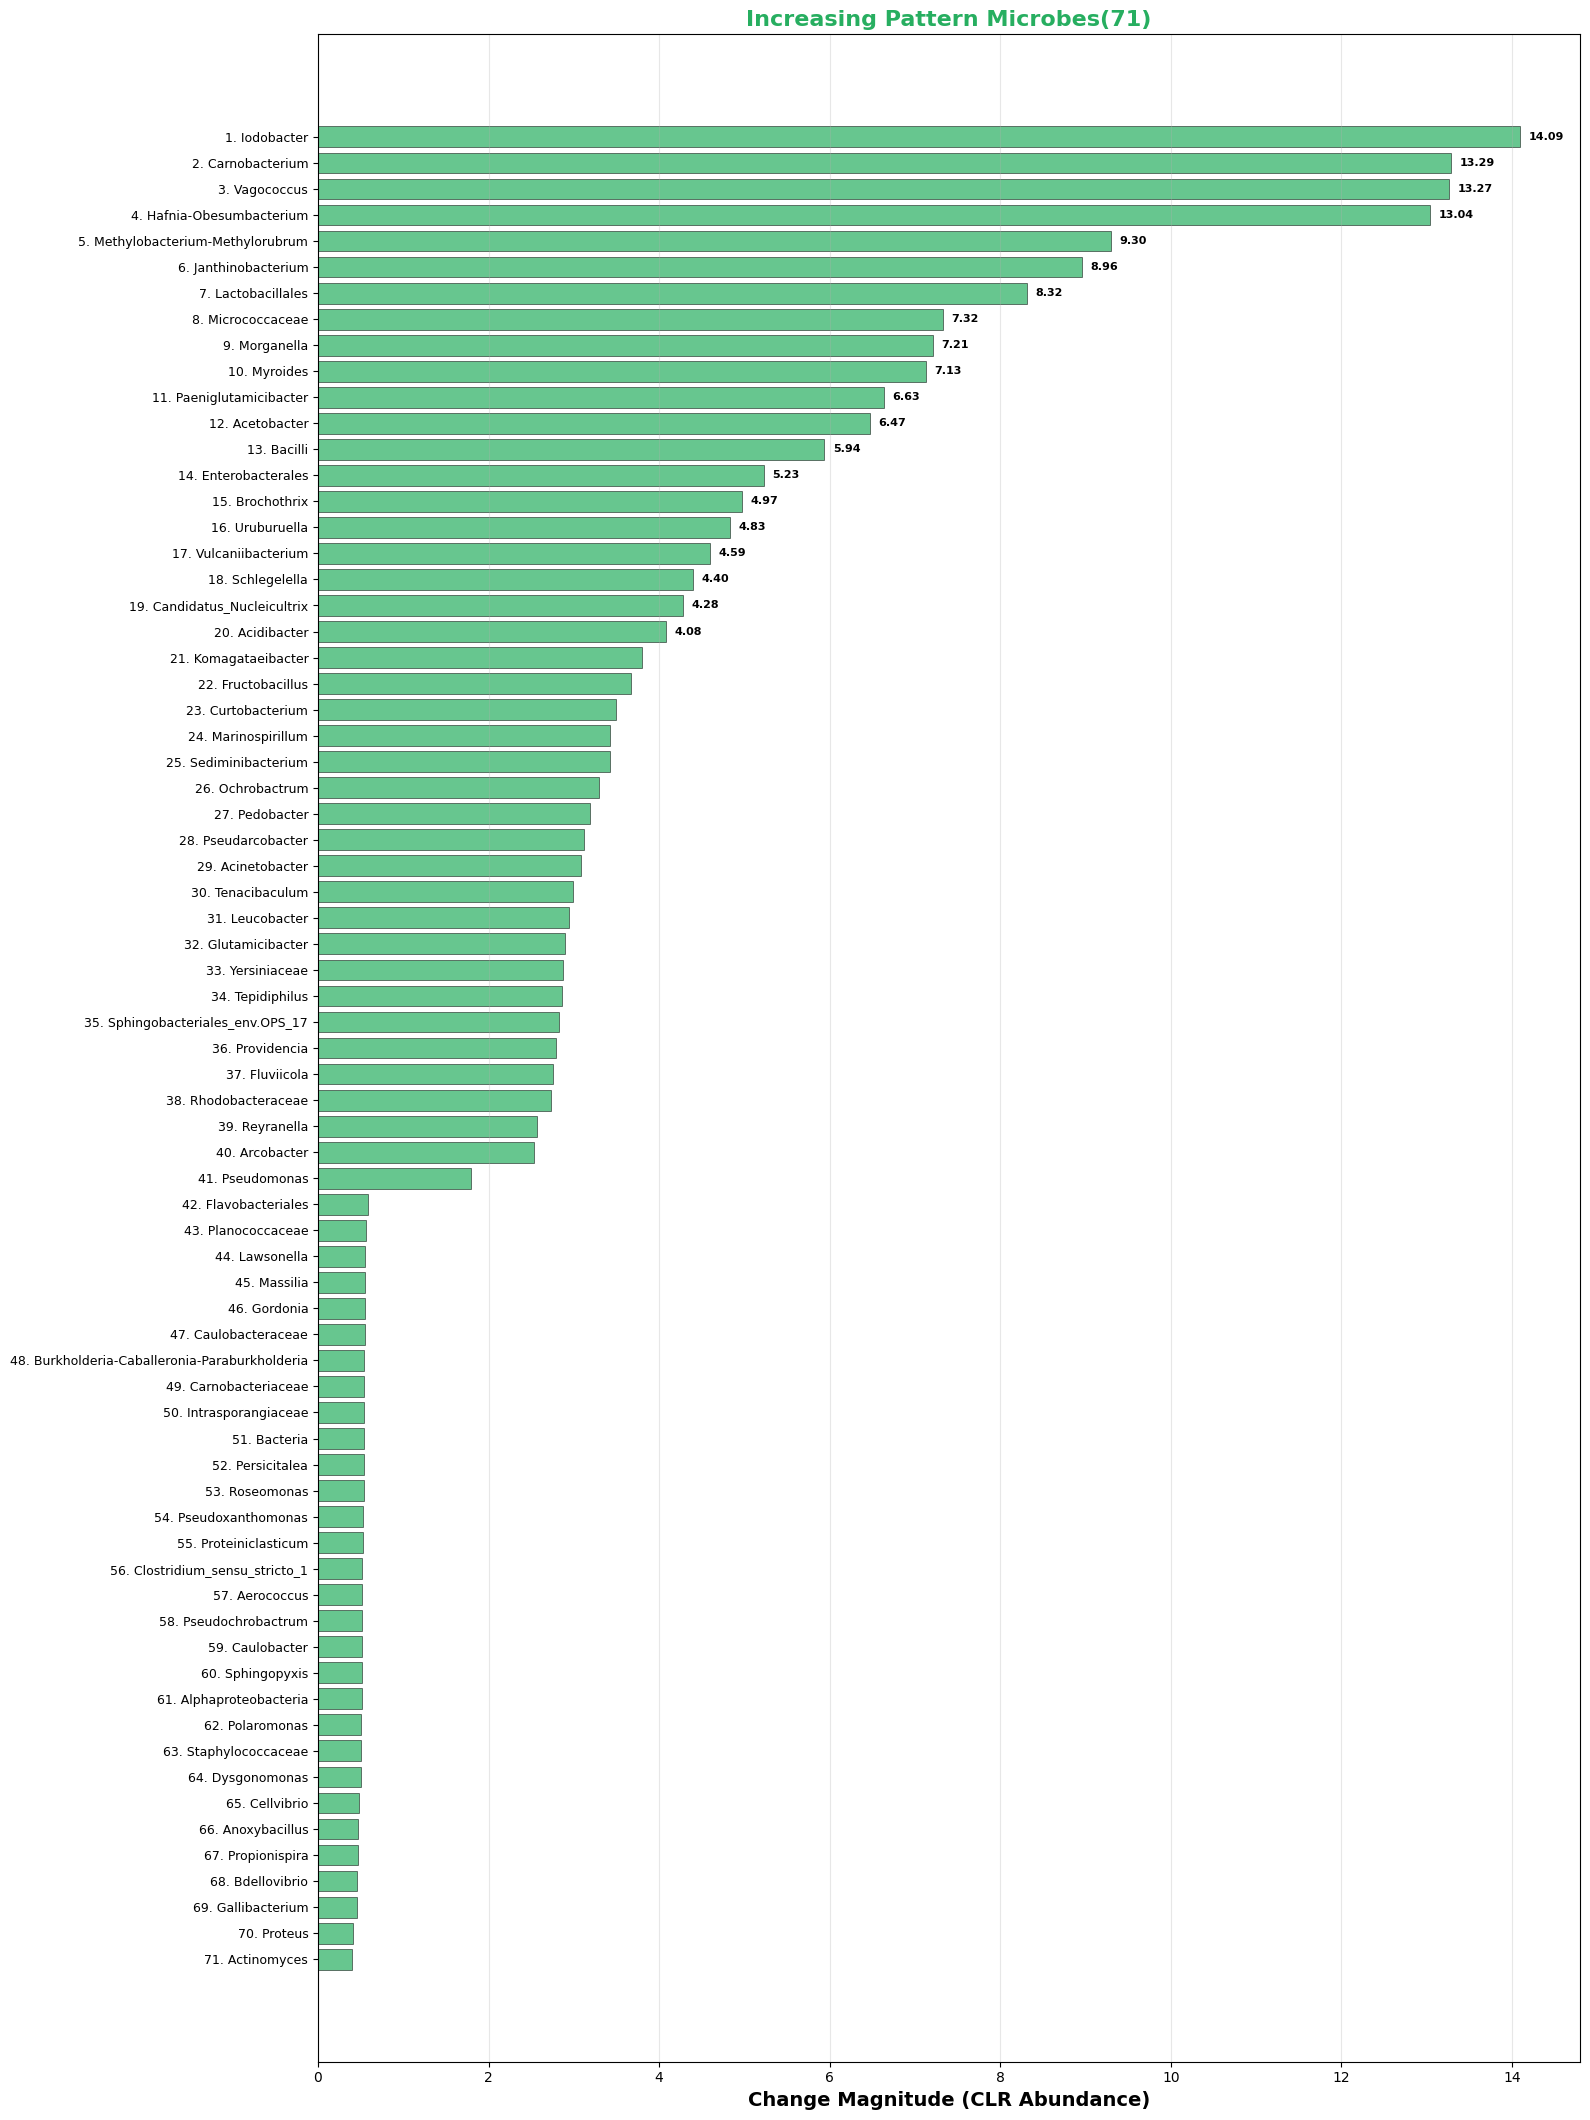


=== Increasing Pattern Analysis ===
📈 Total increasing species: 71
🔬 Average change magnitude: 3.265
📊 Change magnitude range: 0.395 ~ 14.093
📊 Mean CLR abundance range: -0.752 ~ 15.657

=== Top 10 Most Increasing Microbes ===
----------------------------------------------------------------------
Rank Genus                          Change Magnitude Mean CLR  
----------------------------------------------------------------------
1    Iodobacter                     14.093          6.621     
2    Carnobacterium                 13.290          2.676     
3    Vagococcus                     13.266          3.093     
4    Hafnia-Obesumbacterium         13.038          1.917     
5    Methylobacterium-Methylorubru  9.299           8.047     
6    Janthinobacterium              8.957           10.800    
7    Lactobacillales                8.318           9.171     
8    Micrococcaceae                 7.324           10.063    
9    Morganella                     7.208           0.030     

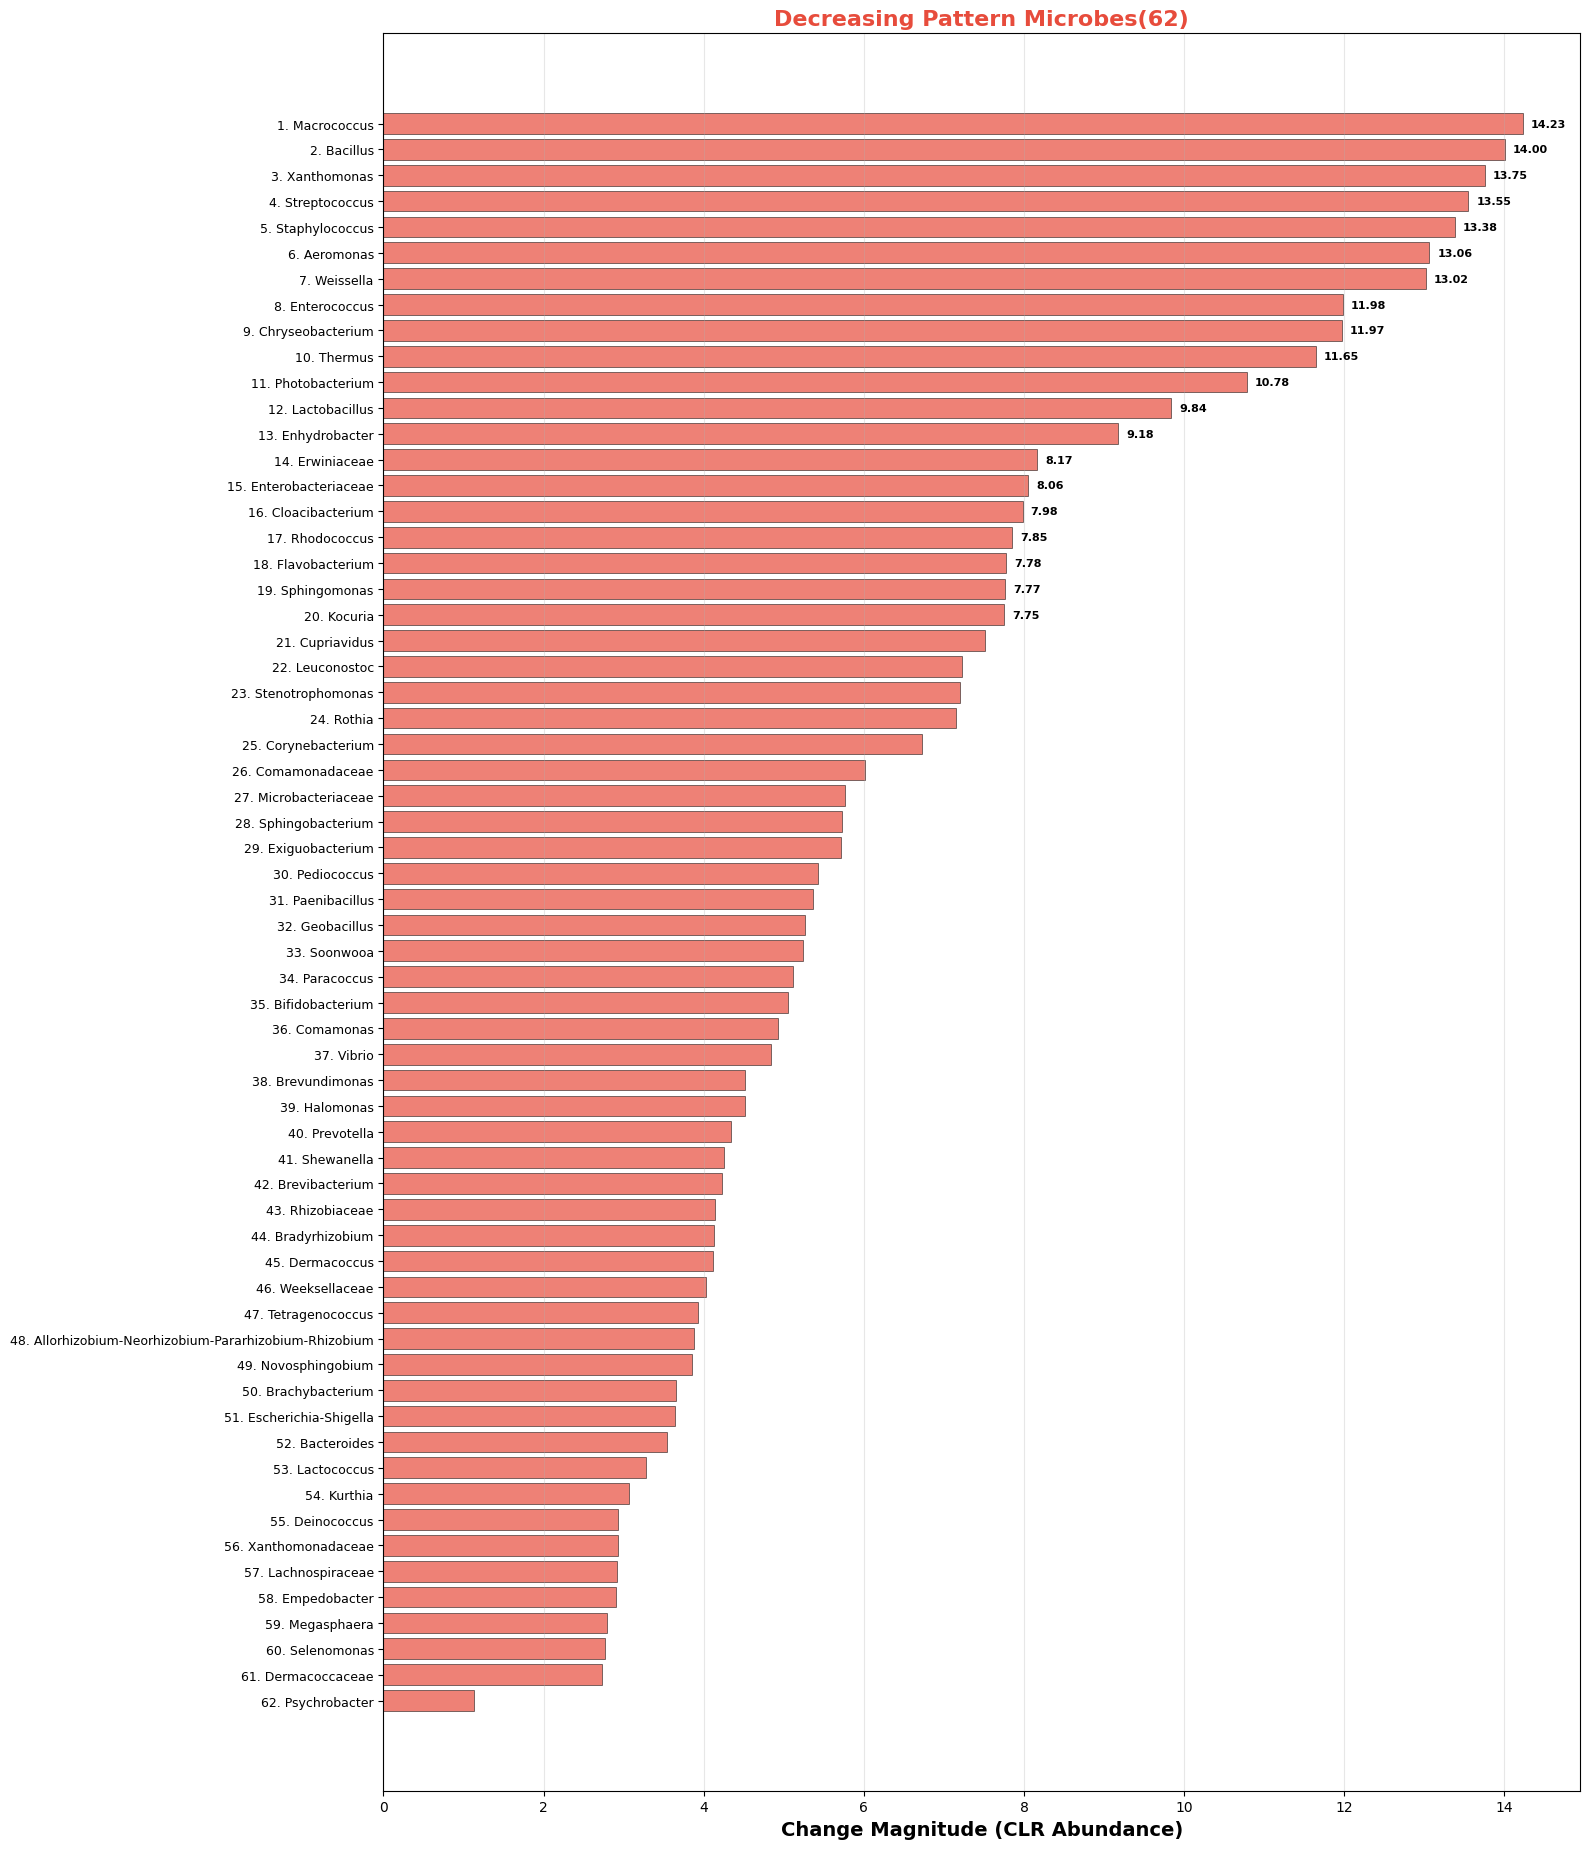


=== Decreasing Pattern Analysis ===
📉 Total decreasing species: 62
🔬 Average change magnitude: 6.520
📊 Change magnitude range: 1.129 ~ 14.234
📊 Mean CLR abundance range: -0.447 ~ 14.771

=== Top 10 Most Decreasing Microbes ===
----------------------------------------------------------------------
Rank Genus                          Change Magnitude Mean CLR  
----------------------------------------------------------------------
1    Macrococcus                    14.234          8.923     
2    Bacillus                       14.004          8.404     
3    Xanthomonas                    13.753          7.577     
4    Streptococcus                  13.549          7.569     
5    Staphylococcus                 13.381          7.370     
6    Aeromonas                      13.063          6.686     
7    Weissella                      13.022          6.578     
8    Enterococcus                   11.981          3.551     
9    Chryseobacterium               11.968          6.964     

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

def create_separate_pattern_figures():
    """
    증가 패턴과 감소 패턴을 각각 별도 figure로 시각화하여 모든 feature 표시
    """
    
    # Genus level 데이터 추출
    genus_data = anova_results['Genus']['significant_data']
    if genus_data.empty:
        print("Genus level에서 유의미한 feature가 없습니다.")
        return
    
    # Feature 컬럼만 추출
    genus_features = [col for col in genus_data.columns if col.startswith('g__') and col != 'Description']
    total_features = len(genus_features)
    
    # 미생물 이름 정리 함수
    def clean_genus_name(name):
        clean_name = name.replace('g__', '')
        if '(' in clean_name:
            clean_name = clean_name.split('(')[0].strip()
        return clean_name
    
    # Day별 평균 abundance 계산
    genus_data_copy = genus_data.copy()
    genus_data_copy['Day'] = genus_data_copy['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    day_means = genus_data_copy.groupby('Day')[genus_features].mean()
    
    # 변화량 및 패턴 분석
    change_magnitude = (day_means.max() - day_means.min()).abs()
    change_direction = (day_means.iloc[-1] - day_means.iloc[0])
    
    # 모든 feature 정보 수집
    all_feature_data = []
    for feat in genus_features:
        clean_name = clean_genus_name(feat)
        magnitude = change_magnitude[feat]
        direction = change_direction[feat]
        pattern = "Increasing" if direction > 0 else "Decreasing"
        mean_abundance = day_means[feat].mean()
        std_abundance = day_means[feat].std()
        
        all_feature_data.append({
            'Feature': feat,
            'Genus': clean_name,
            'Change_Magnitude': magnitude,
            'Change_Direction': direction,
            'Pattern': pattern,
            'Mean_CLR_Abundance': mean_abundance,
            'Std_CLR_Abundance': std_abundance
        })
    
    df_all = pd.DataFrame(all_feature_data)
    
    # 증가 패턴과 감소 패턴으로 분리
    df_increasing = df_all[df_all['Pattern'] == 'Increasing'].sort_values('Change_Magnitude', ascending=False)
    df_decreasing = df_all[df_all['Pattern'] == 'Decreasing'].sort_values('Change_Magnitude', ascending=False)
    
    print(f"\n=== Pattern Analysis Summary ===")
    print(f"📊 Total significant features: {total_features}")
    print(f"📈 Increasing pattern: {len(df_increasing)} features ({len(df_increasing)/total_features*100:.1f}%)")
    print(f"📉 Decreasing pattern: {len(df_decreasing)} features ({len(df_decreasing)/total_features*100:.1f}%)")
    
    return create_increasing_figure(df_increasing), create_decreasing_figure(df_decreasing)

def create_increasing_figure(df_increasing):
    """
    Increasing Pattern 미생물들 시각화 (막대 그래프만)
    """
    if df_increasing.empty:
        print("증가 패턴 미생물이 없습니다.")
        return None
    
    num_features = len(df_increasing)
    
    # Figure 크기 동적 조정 (feature 개수에 따라)
    fig_height = max(12, num_features * 0.3)
    fig = plt.figure(figsize=(16, fig_height))
    
    # 모든 증가 패턴 feature 막대 차트
    ax = plt.gca()
    
    y_positions = np.arange(len(df_increasing))
    bars = ax.barh(y_positions, df_increasing['Change_Magnitude'], 
                   color='#27AE60', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # y축 라벨: 순위 + 미생물 이름
    labels = [f"{i+1:2d}. {row['Genus']}" for i, (_, row) in enumerate(df_increasing.iterrows())]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Change Magnitude (CLR Abundance)', fontsize=14, fontweight='bold')
    ax.set_title(f'Increasing Pattern Microbes({num_features})', 
                 fontsize=16, fontweight='bold', color='#27AE60')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # 변화량 값을 막대 끝에 표시 (상위 20개만)
    for i, (bar, magnitude) in enumerate(zip(bars[:20], df_increasing['Change_Magnitude'][:20])):
        ax.text(magnitude + 0.1, i, f'{magnitude:.2f}', 
                va='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 상세 통계 출력
    print(f"\n=== Increasing Pattern Analysis ===")
    print(f"📈 Total increasing species: {num_features}")
    print(f"🔬 Average change magnitude: {df_increasing['Change_Magnitude'].mean():.3f}")
    print(f"📊 Change magnitude range: {df_increasing['Change_Magnitude'].min():.3f} ~ {df_increasing['Change_Magnitude'].max():.3f}")
    print(f"📊 Mean CLR abundance range: {df_increasing['Mean_CLR_Abundance'].min():.3f} ~ {df_increasing['Mean_CLR_Abundance'].max():.3f}")
    
    print(f"\n=== Top 10 Most Increasing Microbes ===")
    print("-" * 70)
    print(f"{'Rank':<4} {'Genus':<30} {'Change Magnitude':<15} {'Mean CLR':<10}")
    print("-" * 70)
    for i, (_, row) in enumerate(df_increasing.head(10).iterrows()):
        print(f"{i+1:<4} {row['Genus'][:29]:<30} {row['Change_Magnitude']:<15.3f} {row['Mean_CLR_Abundance']:<10.3f}")
    
    return fig

def create_decreasing_figure(df_decreasing):
    """
    Decreasing Pattern 미생물들 시각화 (막대 그래프만)
    """
    if df_decreasing.empty:
        print("감소 패턴 미생물이 없습니다.")
        return None
    
    num_features = len(df_decreasing)
    
    # Figure 크기 동적 조정
    fig_height = max(12, num_features * 0.3)
    fig = plt.figure(figsize=(16, fig_height))
    
    # 모든 감소 패턴 feature 막대 차트
    ax = plt.gca()
    
    y_positions = np.arange(len(df_decreasing))
    bars = ax.barh(y_positions, df_decreasing['Change_Magnitude'], 
                   color='#E74C3C', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # y축 라벨: 순위 + 미생물 이름
    labels = [f"{i+1:2d}. {row['Genus']}" for i, (_, row) in enumerate(df_decreasing.iterrows())]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Change Magnitude (CLR Abundance)', fontsize=14, fontweight='bold')
    ax.set_title(f'Decreasing Pattern Microbes({num_features})', 
                 fontsize=16, fontweight='bold', color='#E74C3C')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # 변화량 값을 막대 끝에 표시 (상위 20개만)
    for i, (bar, magnitude) in enumerate(zip(bars[:20], df_decreasing['Change_Magnitude'][:20])):
        ax.text(magnitude + 0.1, i, f'{magnitude:.2f}', 
                va='center', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 상세 통계 출력
    print(f"\n=== Decreasing Pattern Analysis ===")
    print(f"📉 Total decreasing species: {num_features}")
    print(f"🔬 Average change magnitude: {df_decreasing['Change_Magnitude'].mean():.3f}")
    print(f"📊 Change magnitude range: {df_decreasing['Change_Magnitude'].min():.3f} ~ {df_decreasing['Change_Magnitude'].max():.3f}")
    print(f"📊 Mean CLR abundance range: {df_decreasing['Mean_CLR_Abundance'].min():.3f} ~ {df_decreasing['Mean_CLR_Abundance'].max():.3f}")
    
    print(f"\n=== Top 10 Most Decreasing Microbes ===")
    print("-" * 70)
    print(f"{'Rank':<4} {'Genus':<30} {'Change Magnitude':<15} {'Mean CLR':<10}")
    print("-" * 70)
    for i, (_, row) in enumerate(df_decreasing.head(10).iterrows()):
        print(f"{i+1:<4} {row['Genus'][:29]:<30} {row['Change_Magnitude']:<15.3f} {row['Mean_CLR_Abundance']:<10.3f}")
    
    return fig

def create_complete_species_list():
    """
    133개 모든 미생물 종의 완전한 목록을 표 형태로 출력
    """
    genus_data = anova_results['Genus']['significant_data']
    if genus_data.empty:
        return
    
    genus_features = [col for col in genus_data.columns if col.startswith('g__') and col != 'Description']
    
    def clean_genus_name(name):
        clean_name = name.replace('g__', '')
        if '(' in clean_name:
            clean_name = clean_name.split('(')[0].strip()
        return clean_name
    
    genus_data_copy = genus_data.copy()
    genus_data_copy['Day'] = genus_data_copy['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    day_means = genus_data_copy.groupby('Day')[genus_features].mean()
    
    change_magnitude = (day_means.max() - day_means.min()).abs()
    change_direction = (day_means.iloc[-1] - day_means.iloc[0])
    
    # 전체 feature 테이블 생성
    complete_table = pd.DataFrame({
        'Feature_ID': genus_features,
        'Genus_Name': [clean_genus_name(feat) for feat in genus_features],
        'Change_Magnitude': [change_magnitude[feat] for feat in genus_features],
        'Change_Direction': [change_direction[feat] for feat in genus_features],
        'Pattern': ['Increasing' if change_direction[feat] > 0 else 'Decreasing' for feat in genus_features],
        'Mean_CLR': [day_means[feat].mean() for feat in genus_features],
        'Day_1_CLR': [day_means[feat].iloc[0] for feat in genus_features],
        'Day_28_CLR': [day_means[feat].iloc[-1] for feat in genus_features]
    })
    
    # 패턴별로 정렬
    increasing_table = complete_table[complete_table['Pattern'] == 'Increasing'].sort_values('Change_Magnitude', ascending=False).reset_index(drop=True)
    decreasing_table = complete_table[complete_table['Pattern'] == 'Decreasing'].sort_values('Change_Magnitude', ascending=False).reset_index(drop=True)
    
    print(f"\n=== Complete Species List (Total: {len(complete_table)} species) ===")
    print(f"\n📈 INCREASING PATTERN SPECIES ({len(increasing_table)} species)")
    print("=" * 120)
    print(f"{'Rank':<4} {'Genus Name':<35} {'Change Mag.':<12} {'Mean CLR':<10} {'Day 1':<8} {'Day 28':<8}")
    print("=" * 120)
    
    for i, (_, row) in enumerate(increasing_table.iterrows()):
        print(f"{i+1:<4} {row['Genus_Name'][:34]:<35} {row['Change_Magnitude']:<12.3f} "
              f"{row['Mean_CLR']:<10.3f} {row['Day_1_CLR']:<8.3f} {row['Day_28_CLR']:<8.3f}")
    
    print(f"\n📉 DECREASING PATTERN SPECIES ({len(decreasing_table)} species)")
    print("=" * 120)
    print(f"{'Rank':<4} {'Genus Name':<35} {'Change Mag.':<12} {'Mean CLR':<10} {'Day 1':<8} {'Day 28':<8}")
    print("=" * 120)
    
    for i, (_, row) in enumerate(decreasing_table.iterrows()):
        print(f"{i+1:<4} {row['Genus_Name'][:34]:<35} {row['Change_Magnitude']:<12.3f} "
              f"{row['Mean_CLR']:<10.3f} {row['Day_1_CLR']:<8.3f} {row['Day_28_CLR']:<8.3f}")
    
    return complete_table

# 함수 실행
print("=== Comprehensive Pattern-Based Analysis ===")
fig_increasing, fig_decreasing = create_separate_pattern_figures()

print("\n" + "="*120)
complete_species_table = create_complete_species_list()

## =========================================================================

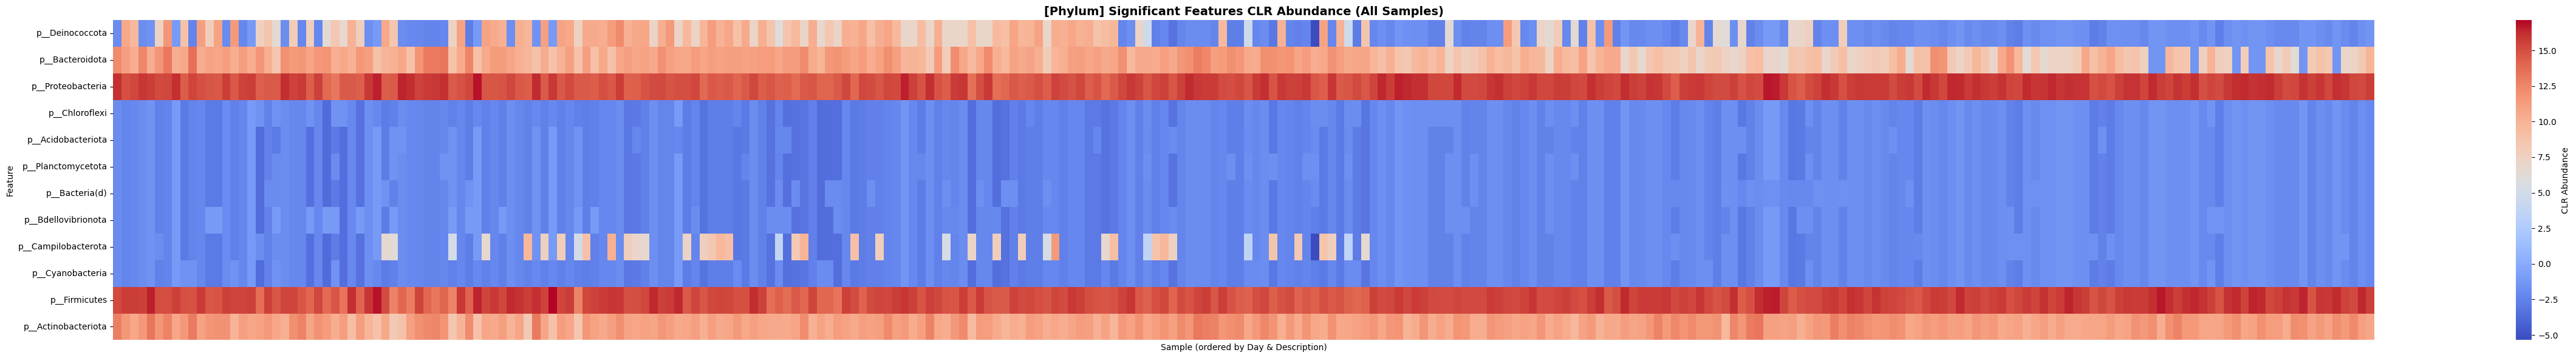

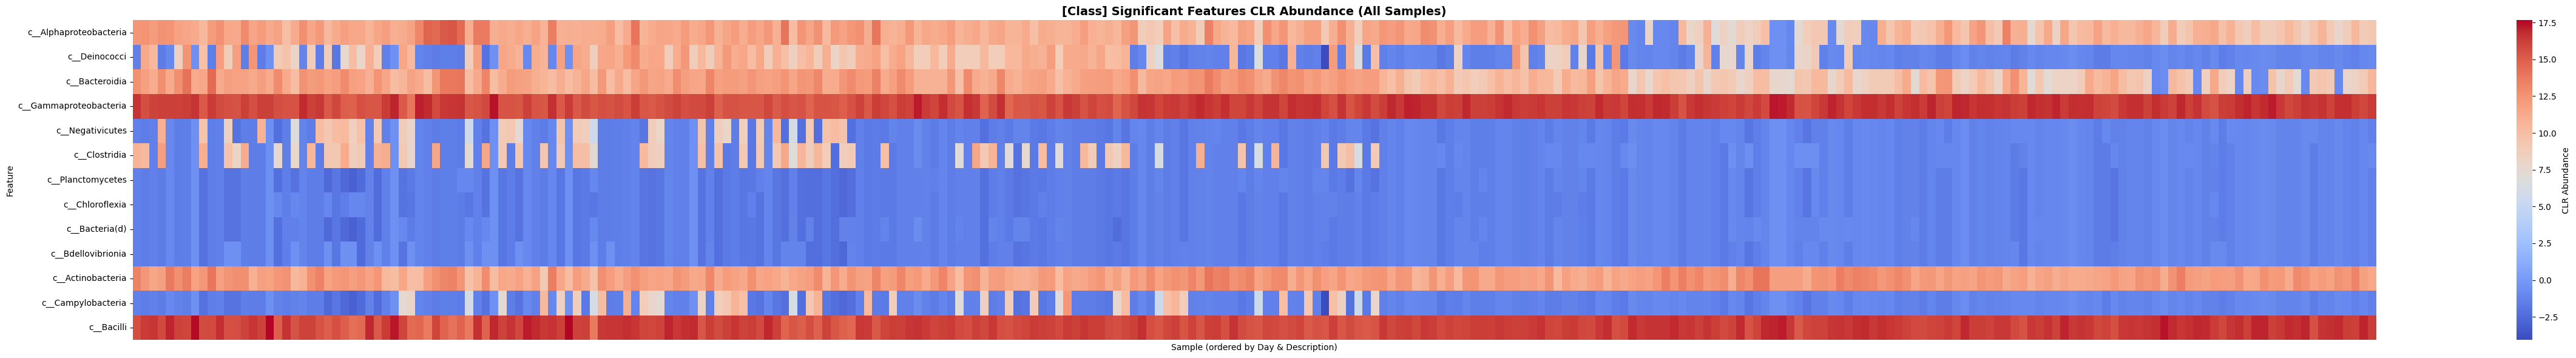

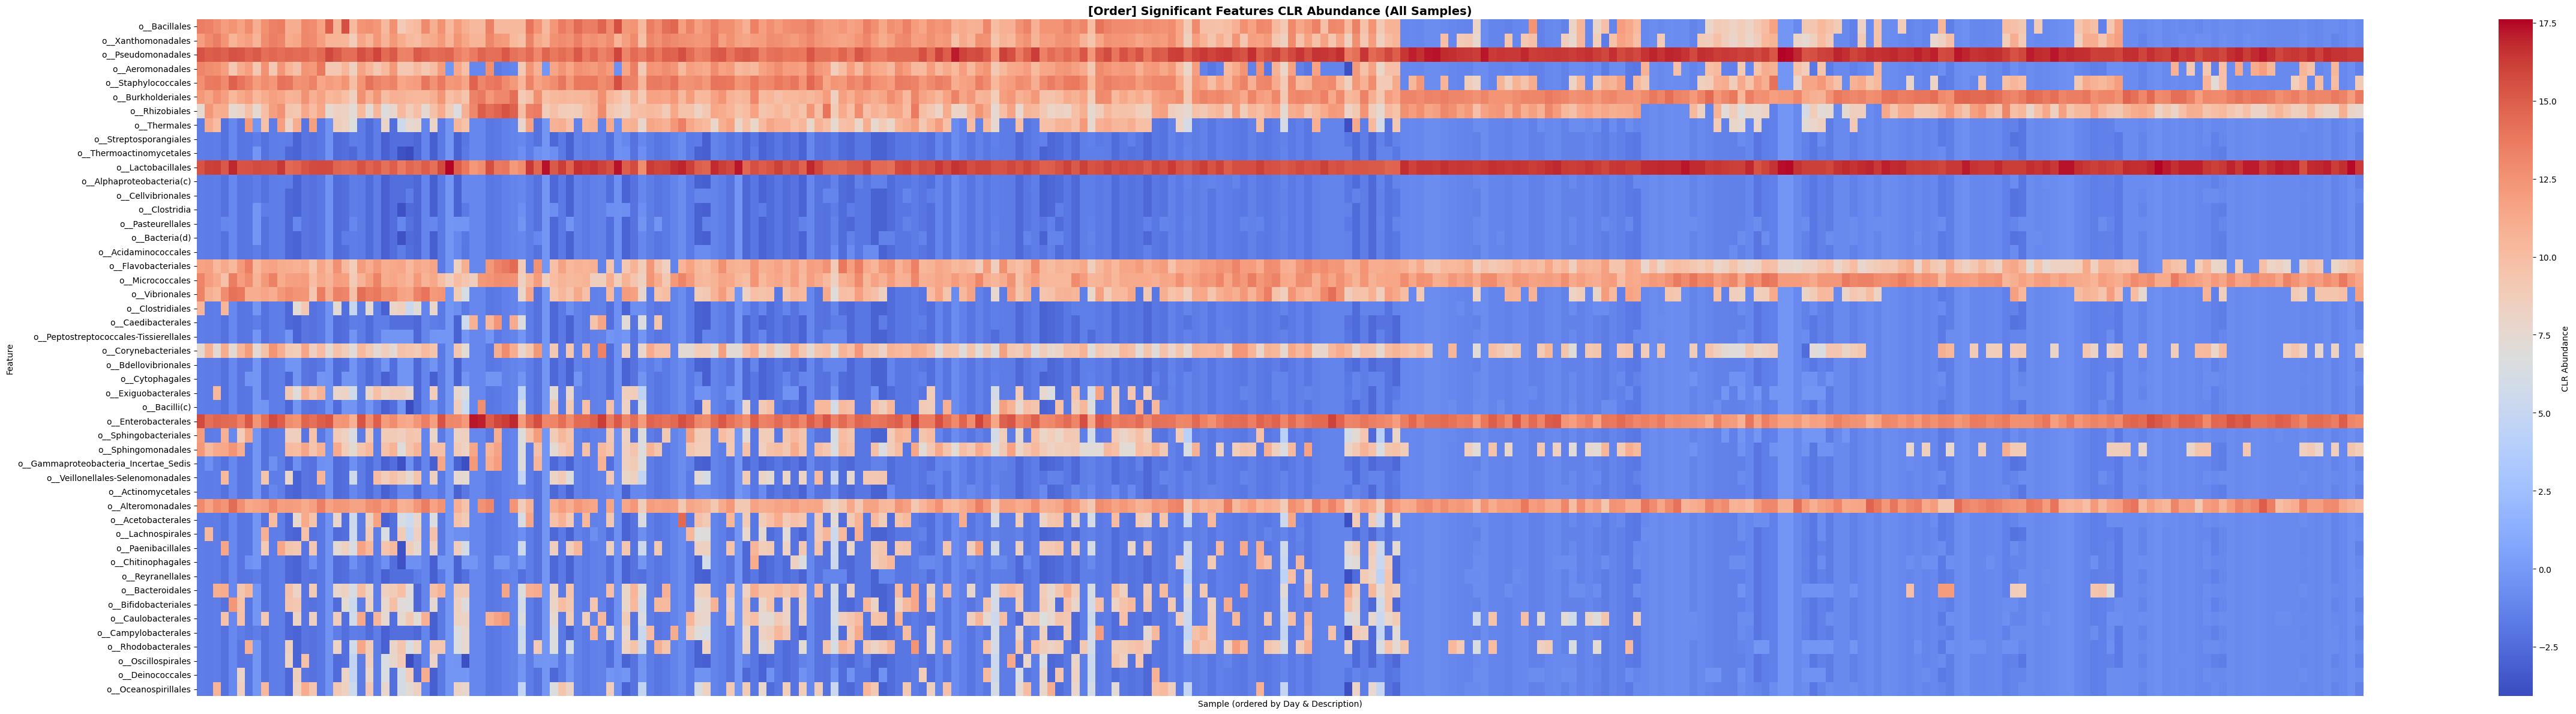

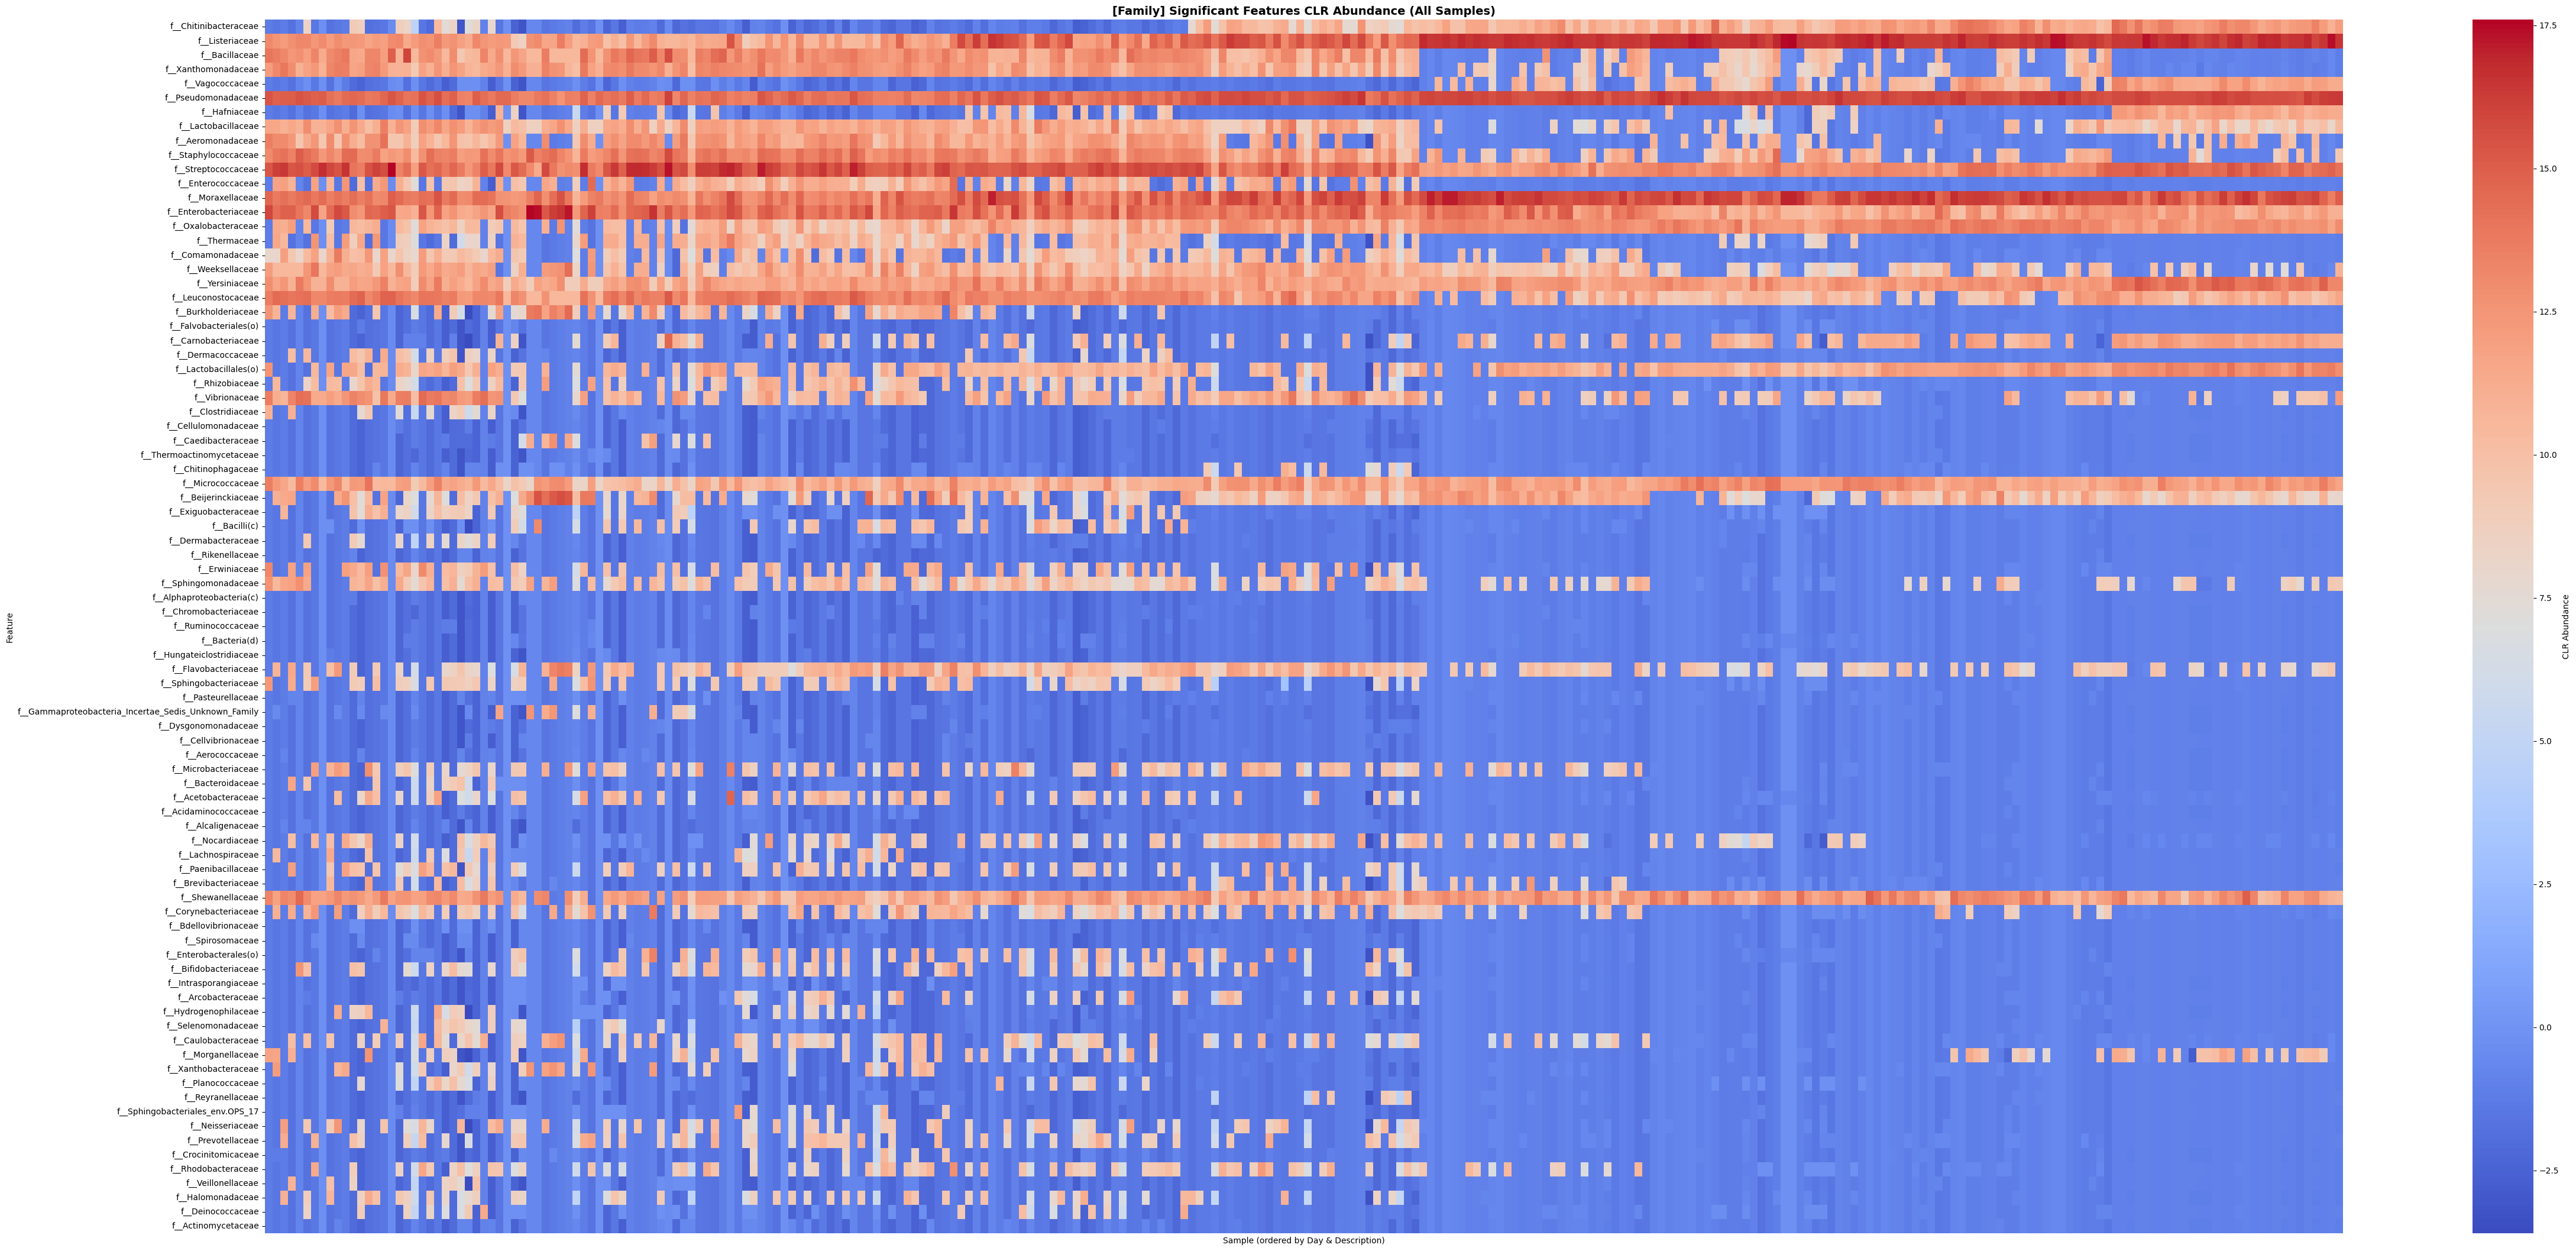

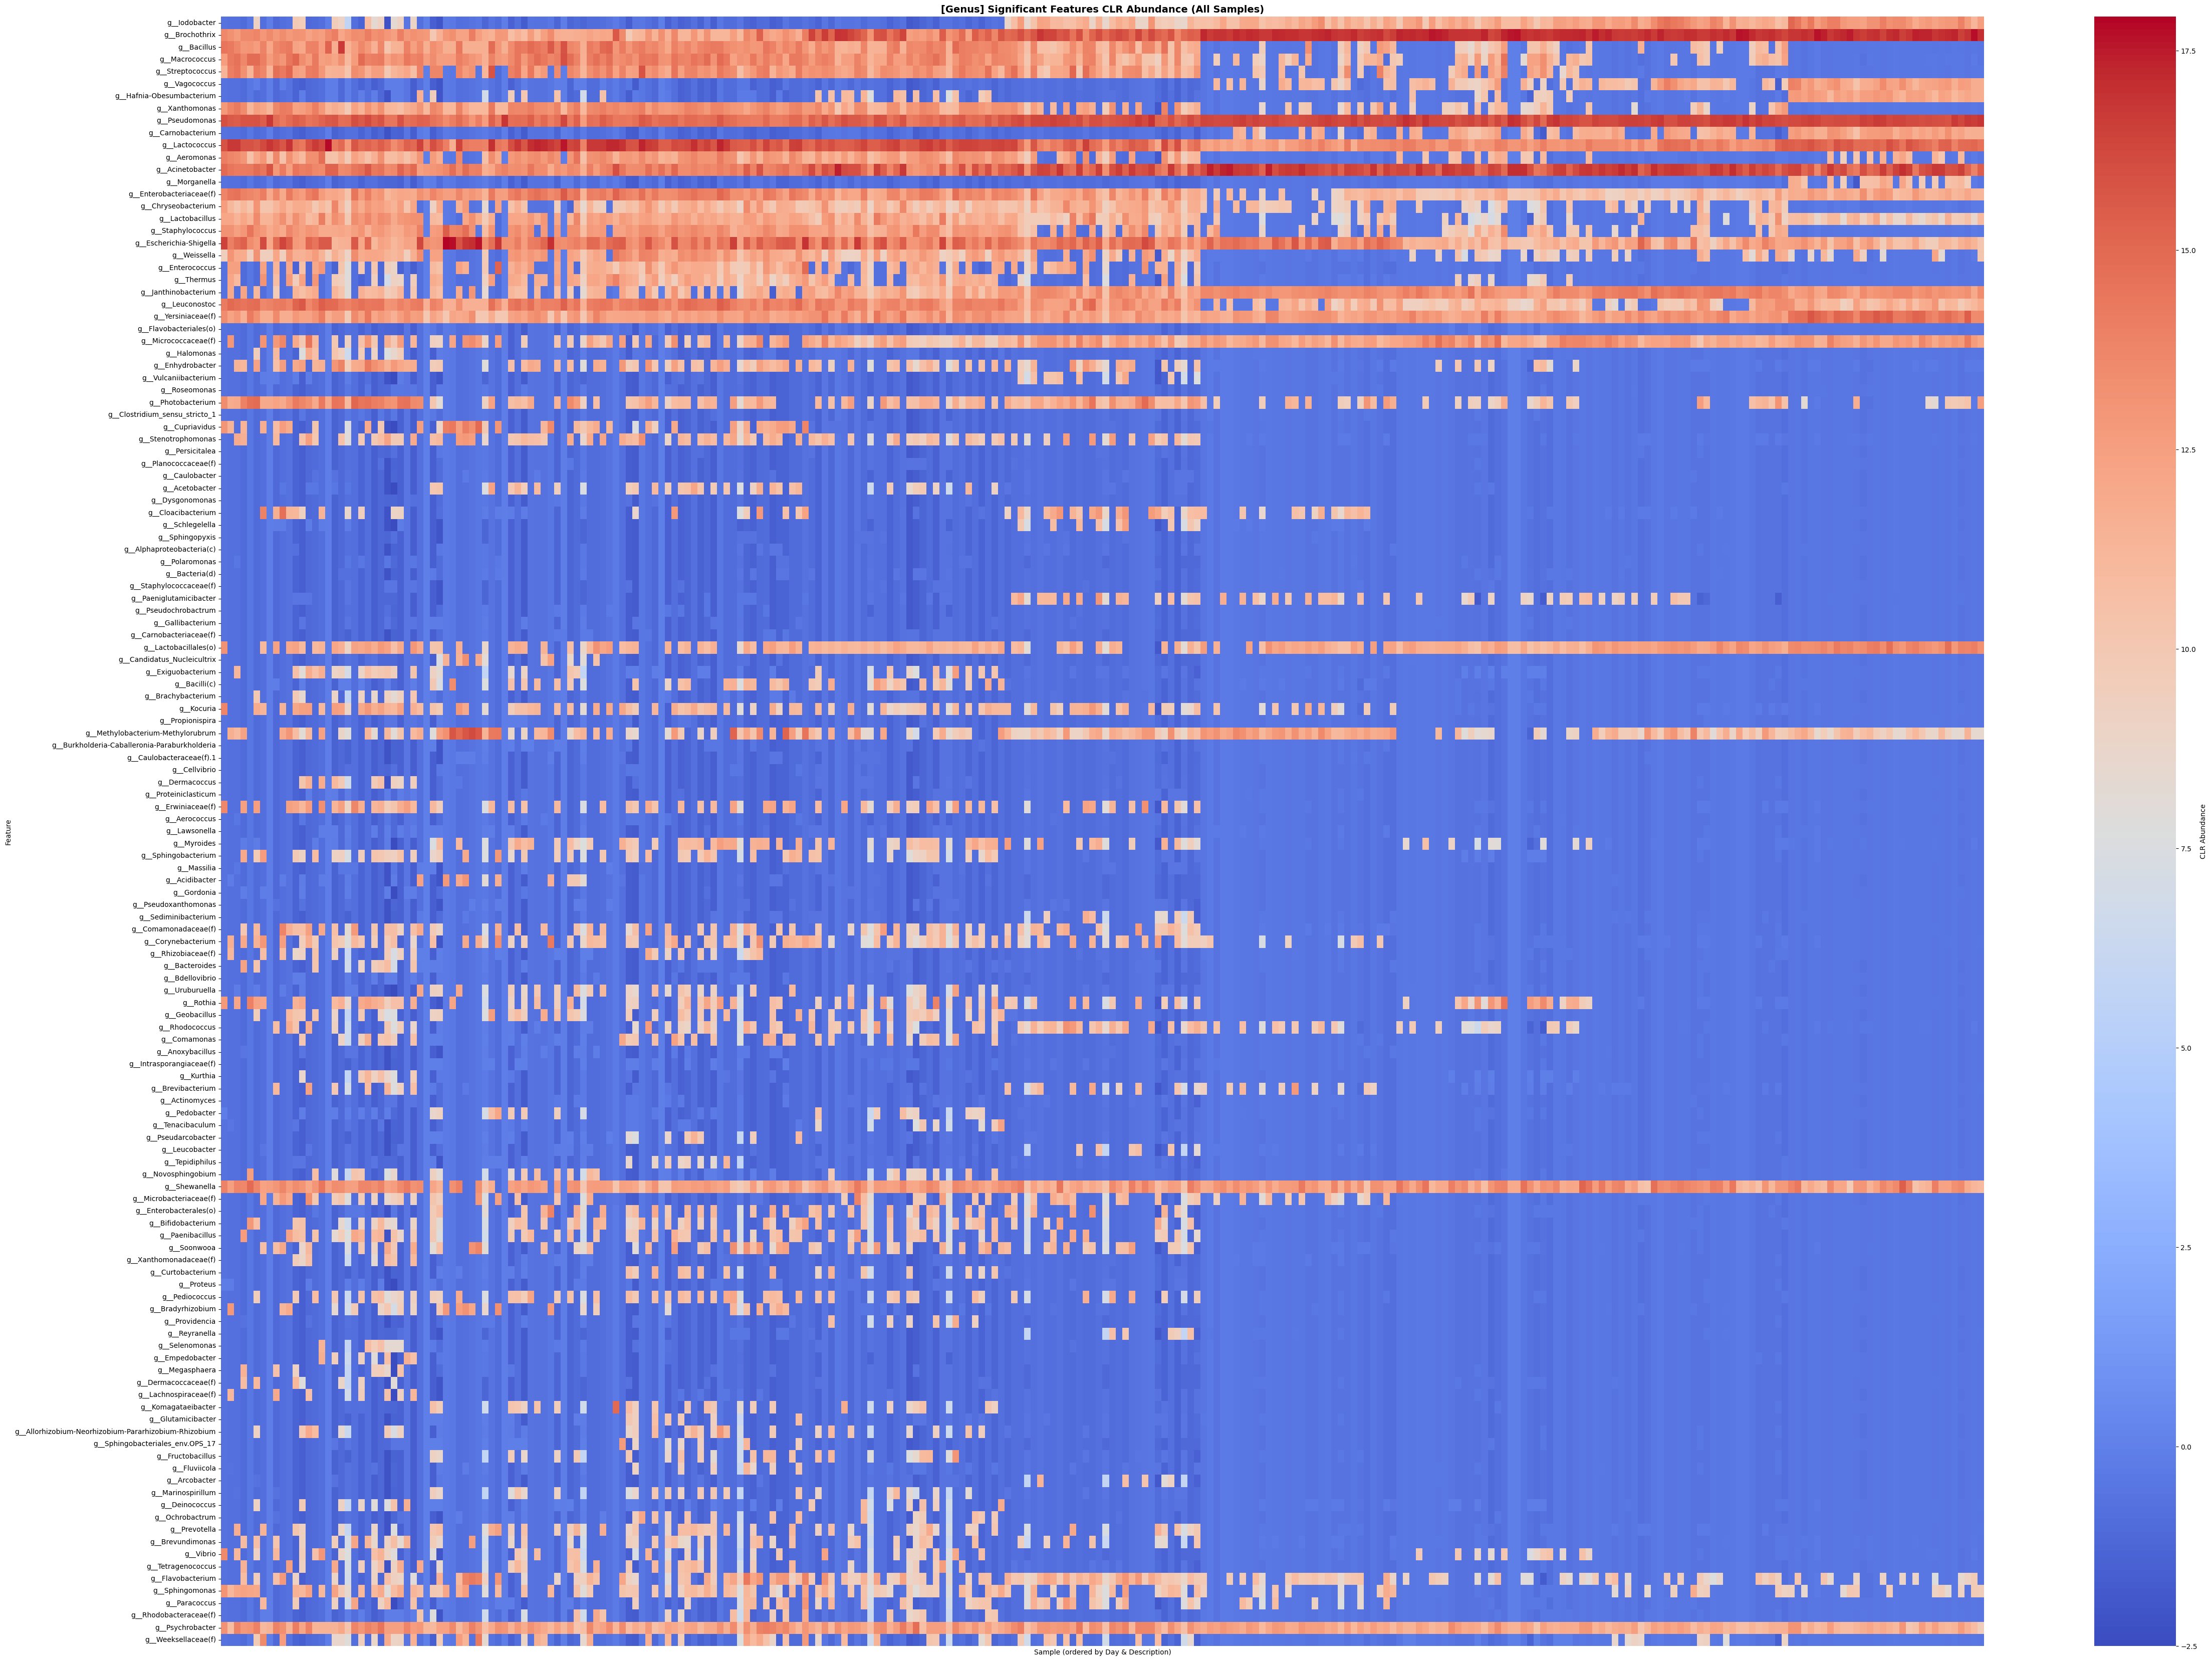

In [13]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Get level names from anova_results
level_names = list(anova_results.keys())

for level_name in level_names:
    sig_data = anova_results[level_name]['significant_data']
    if sig_data is None or sig_data.empty:
        print(f"[{level_name}] No significant features by ANOVA, skipped.")
        continue

    sig_data = sig_data.copy()
    sig_data['Day'] = sig_data['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    feature_cols = [col for col in sig_data.columns if col not in ['Description', 'Day']]

    # Use all significant features (no top 20 limit)
    plot_features = feature_cols

    # Matrix: features x samples
    sample_matrix = sig_data[plot_features].T
    sample_labels = sig_data['Description'].values

    plt.figure(figsize=(max(10, 0.18 * sample_matrix.shape[1]), max(6, 0.25 * len(plot_features))))
    ax = sns.heatmap(
        sample_matrix,
        cmap='coolwarm',
        cbar_kws={'label': 'CLR Abundance'},
        xticklabels=False,
        yticklabels=plot_features
    )
    plt.title(f"[{level_name}] Significant Features CLR Abundance (All Samples)", fontsize=14, fontweight='bold')
    plt.xlabel("Sample (ordered by Day & Description)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

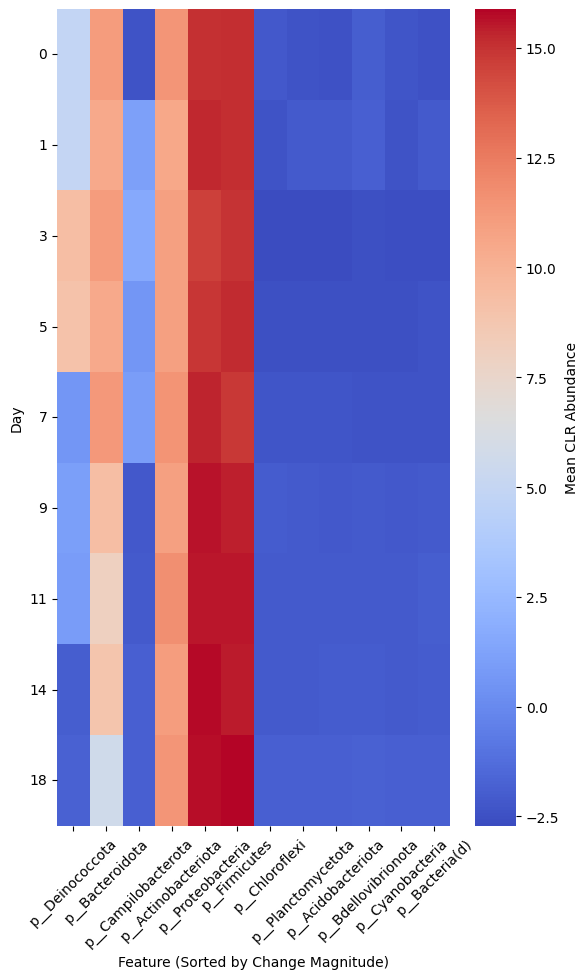

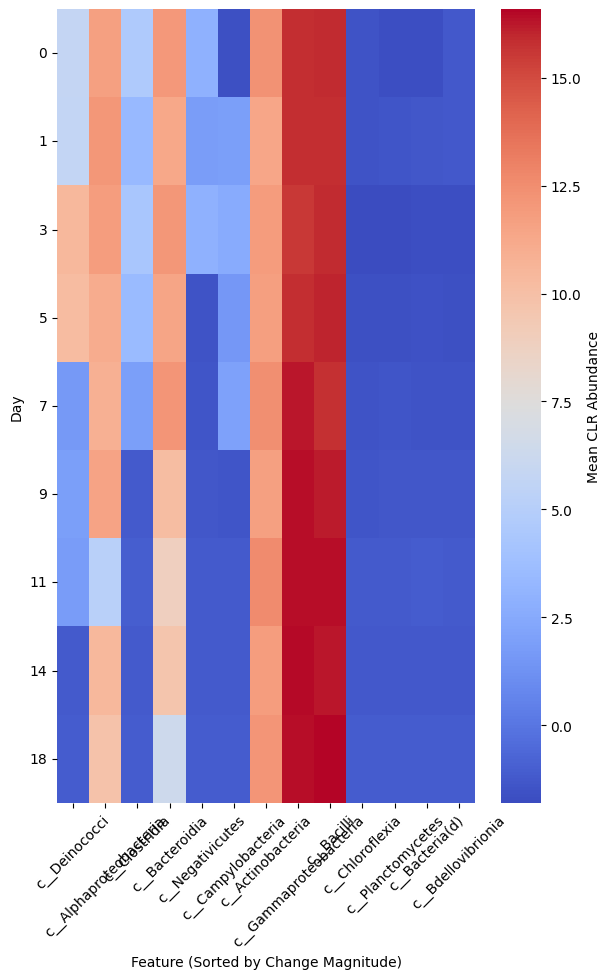

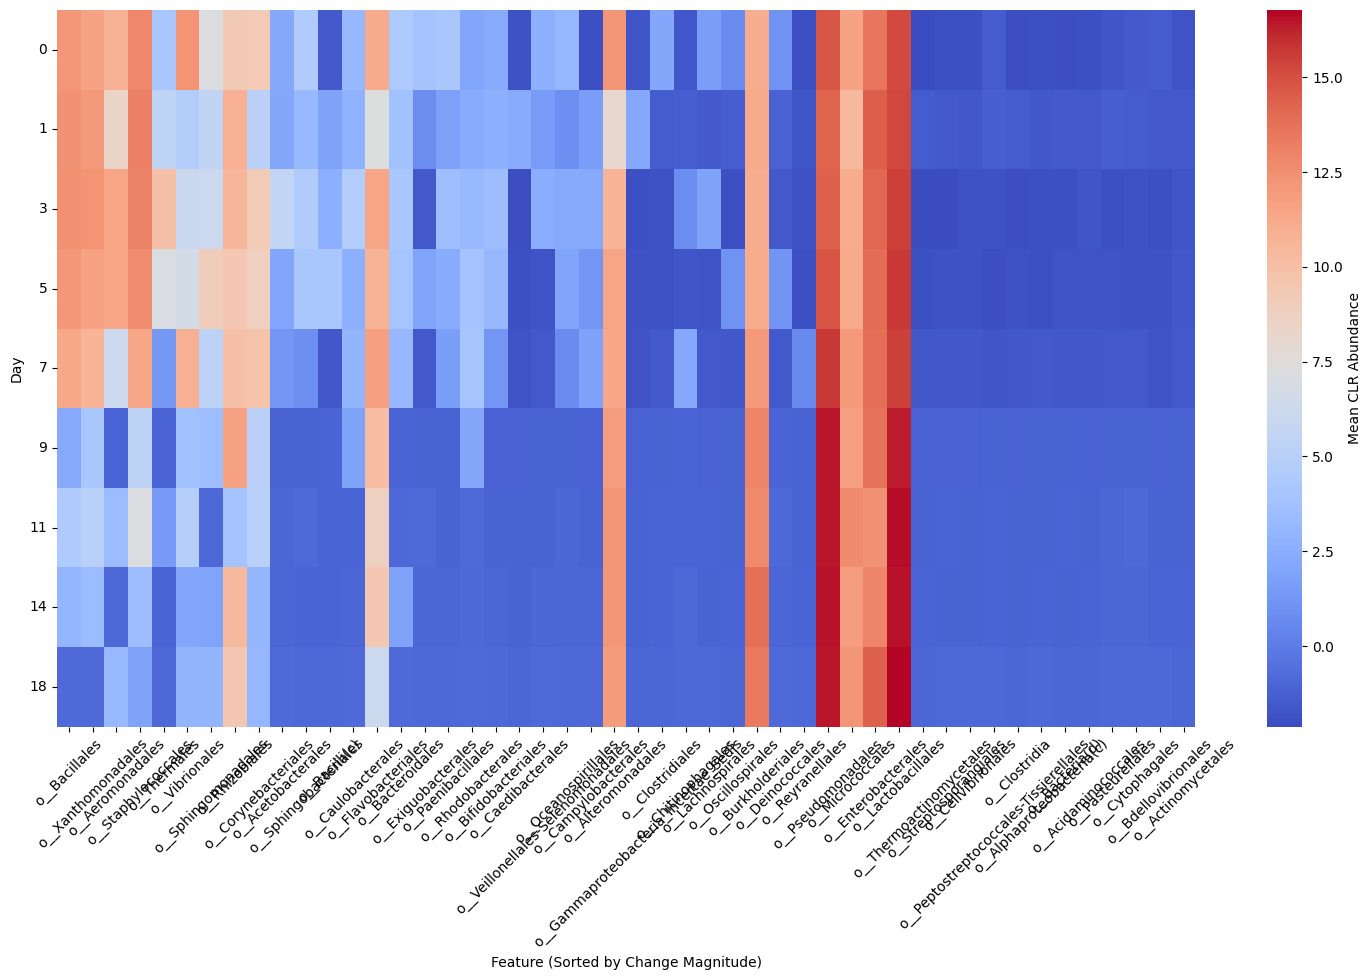

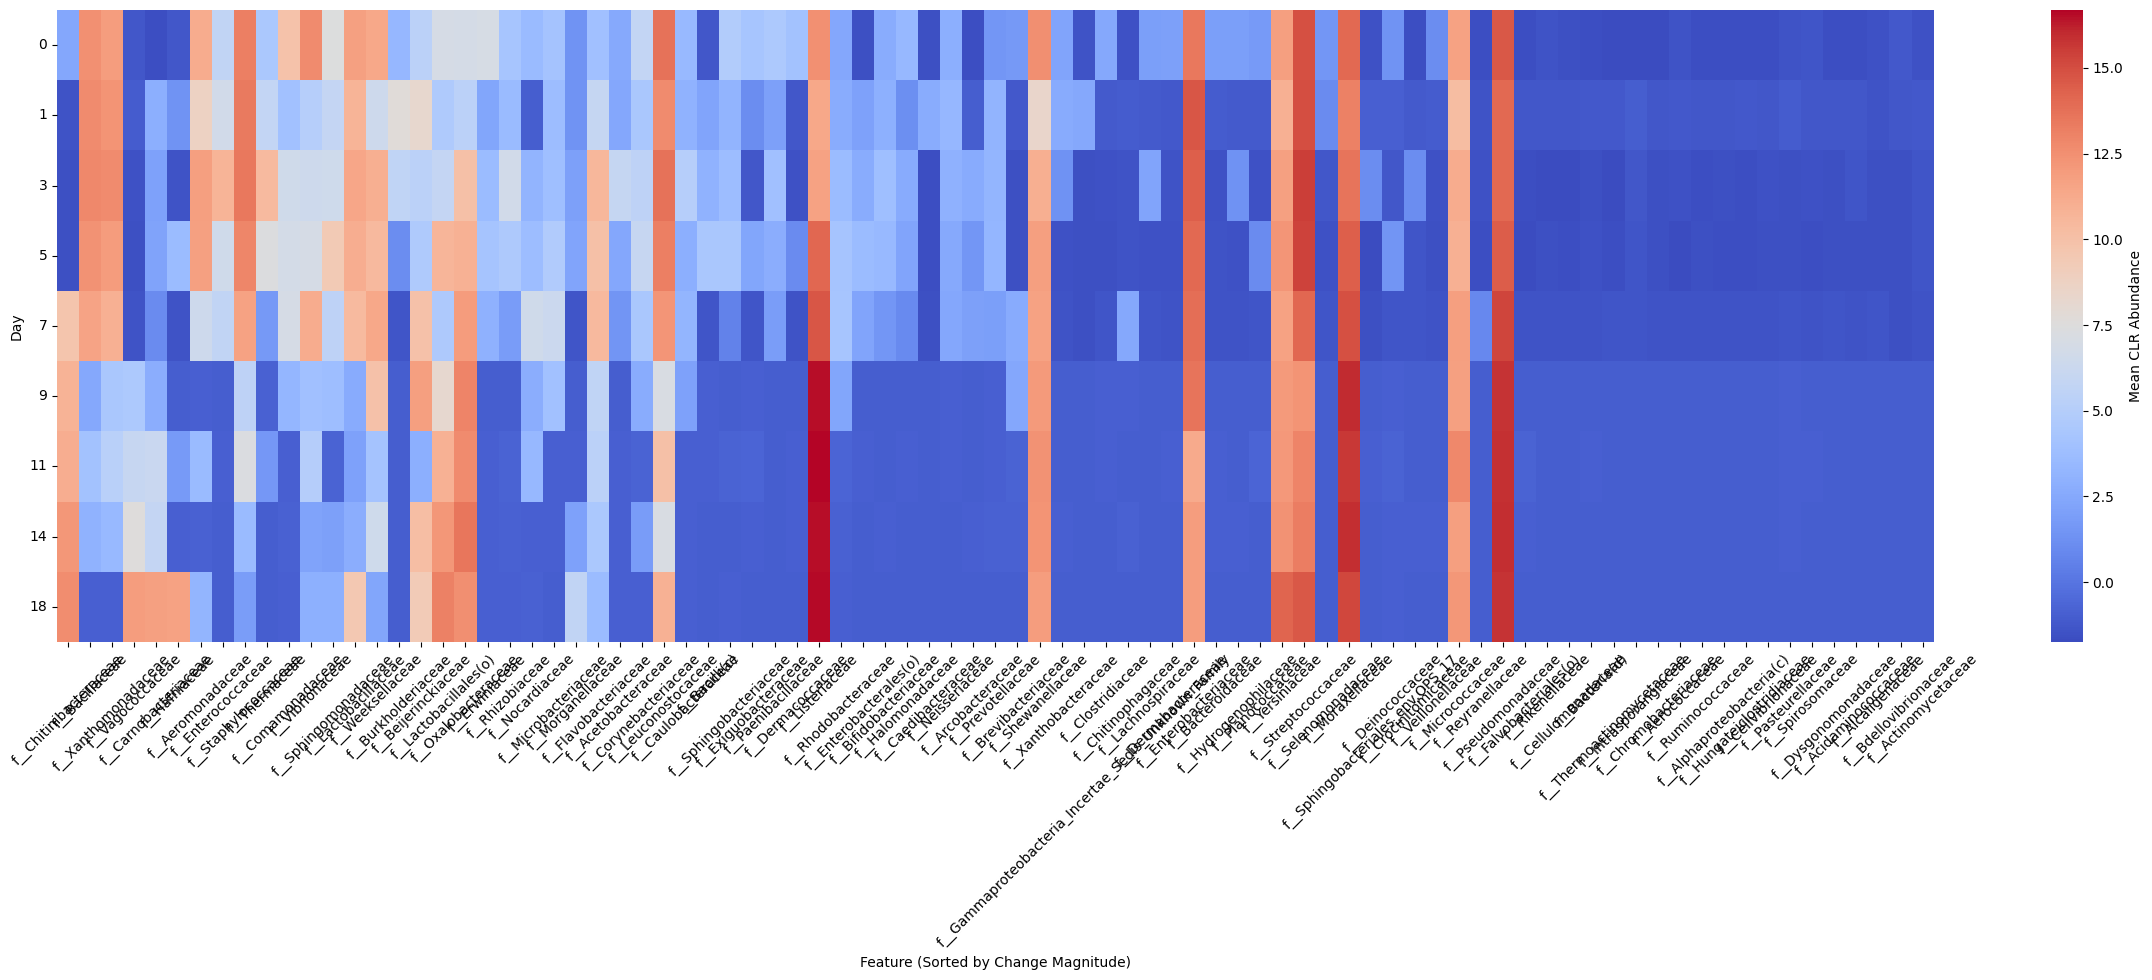

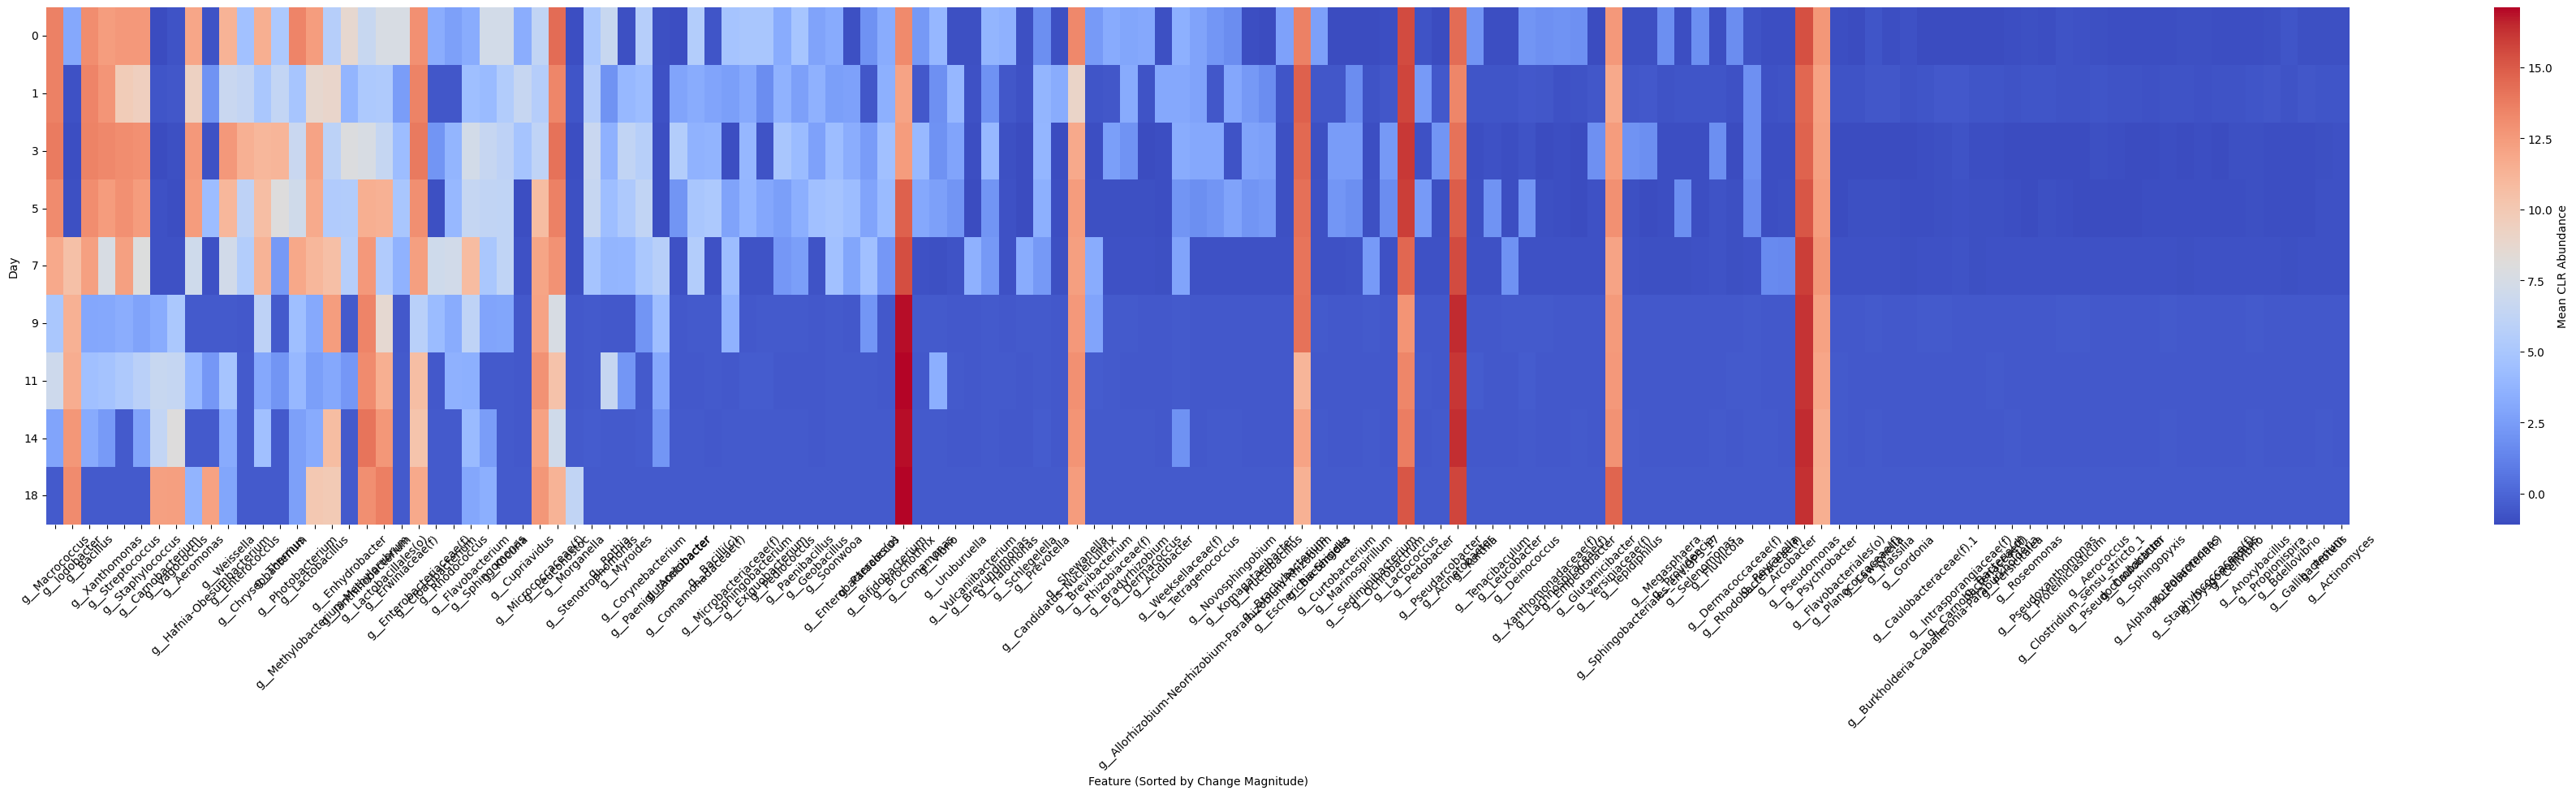

In [17]:
for level_name in level_names:
    sig_data = anova_results[level_name]['significant_data']
    if sig_data is None or sig_data.empty:
        print(f"[{level_name}] No significant features by ANOVA, skipped.")
        continue

    sig_data = sig_data.copy()
    sig_data['Day'] = sig_data['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    feature_cols = [col for col in sig_data.columns if col not in ['Description', 'Day']]

    # 변화율(최대-최소) 기준으로 feature 정렬
    day_mean_df = sig_data.groupby('Day')[feature_cols].mean()
    feature_changes = (day_mean_df.max() - day_mean_df.min()).abs()
    sorted_features = feature_changes.sort_values(ascending=False).index.tolist()

    # 정렬된 feature 순서로 plot
    plot_features = sorted_features

    plt.figure(figsize=(0.25 * len(plot_features) + 3, 1.1 * len(day_mean_df)))
    ax = sns.heatmap(day_mean_df[plot_features], cmap='coolwarm', annot=False, cbar_kws={'label': 'Mean CLR Abundance'})

    plt.xlabel("Feature (Sorted by Change Magnitude)")
    plt.ylabel("Day")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

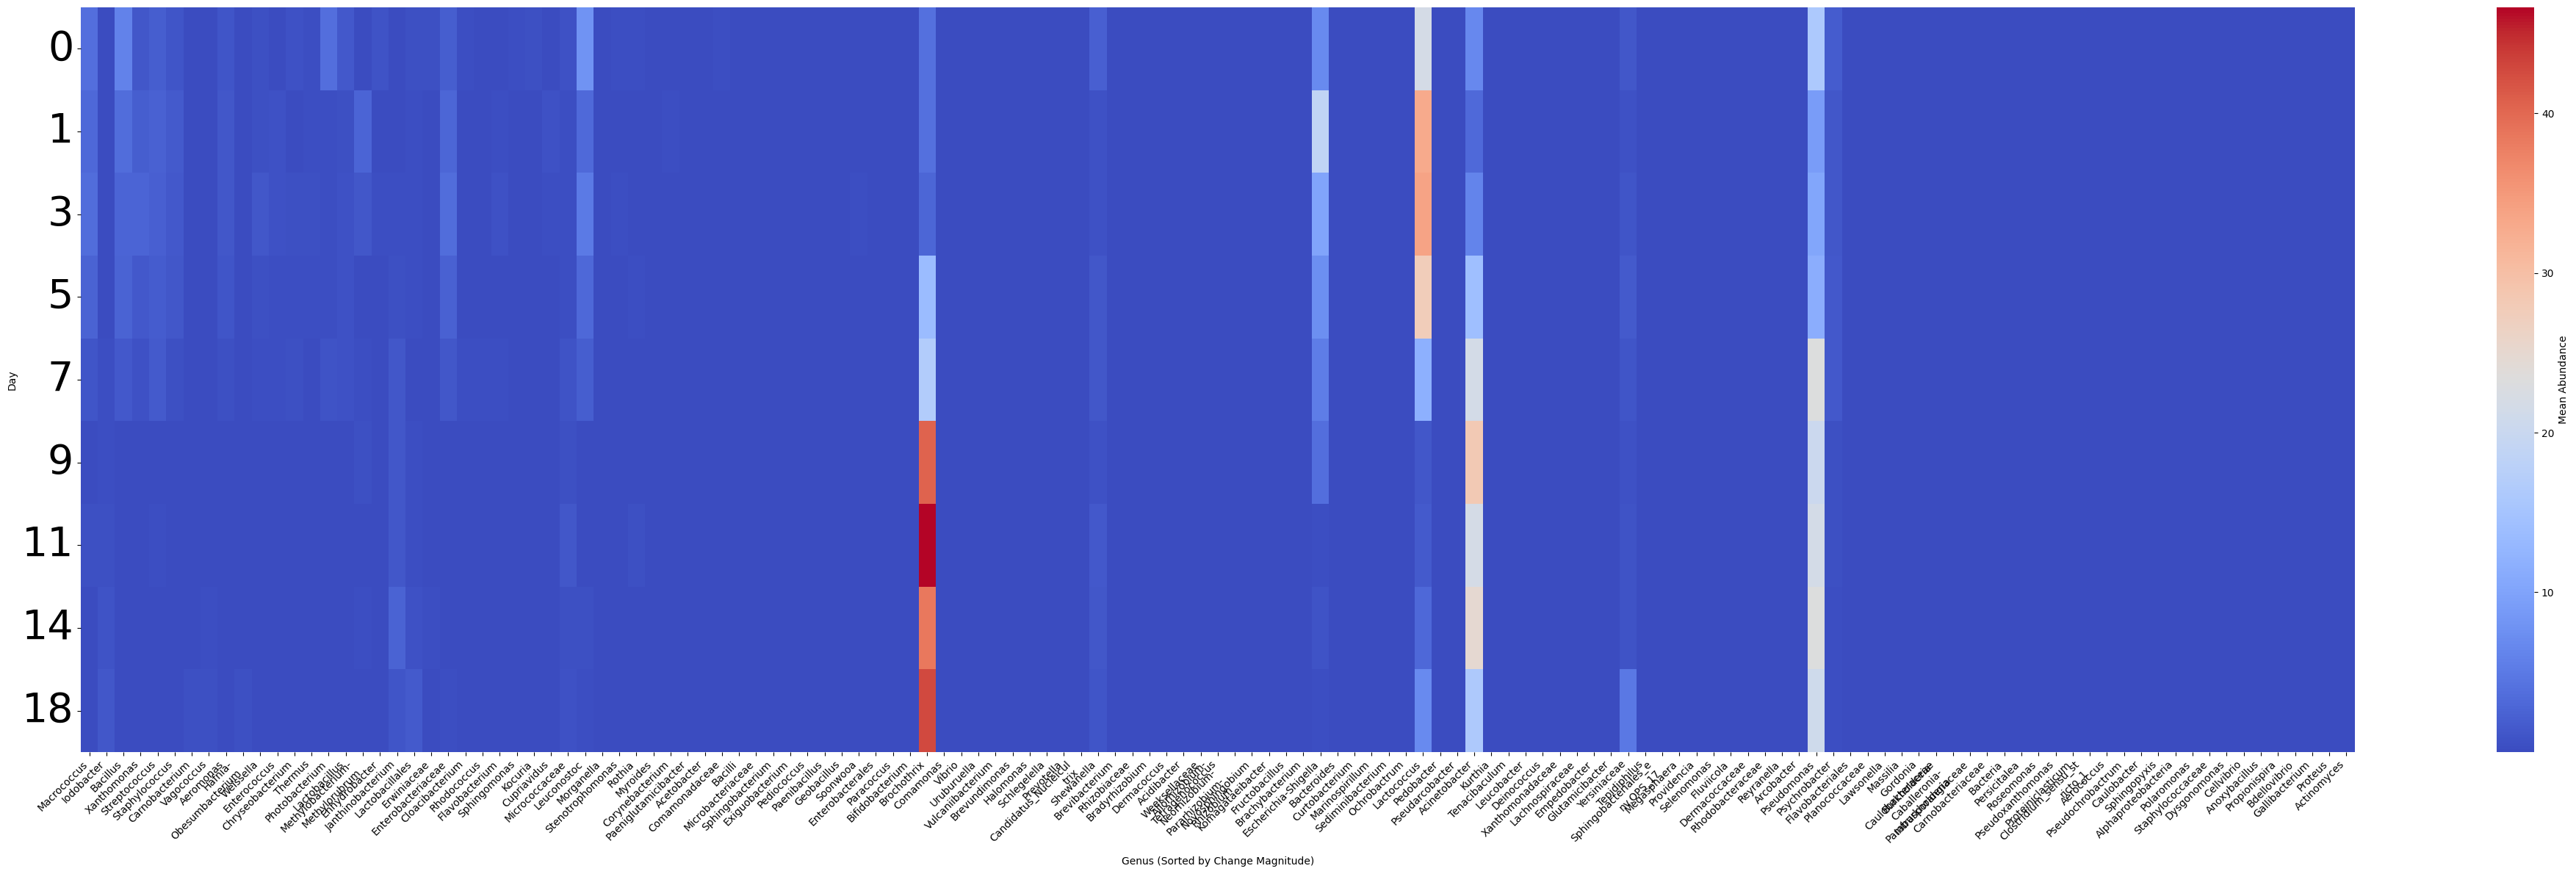

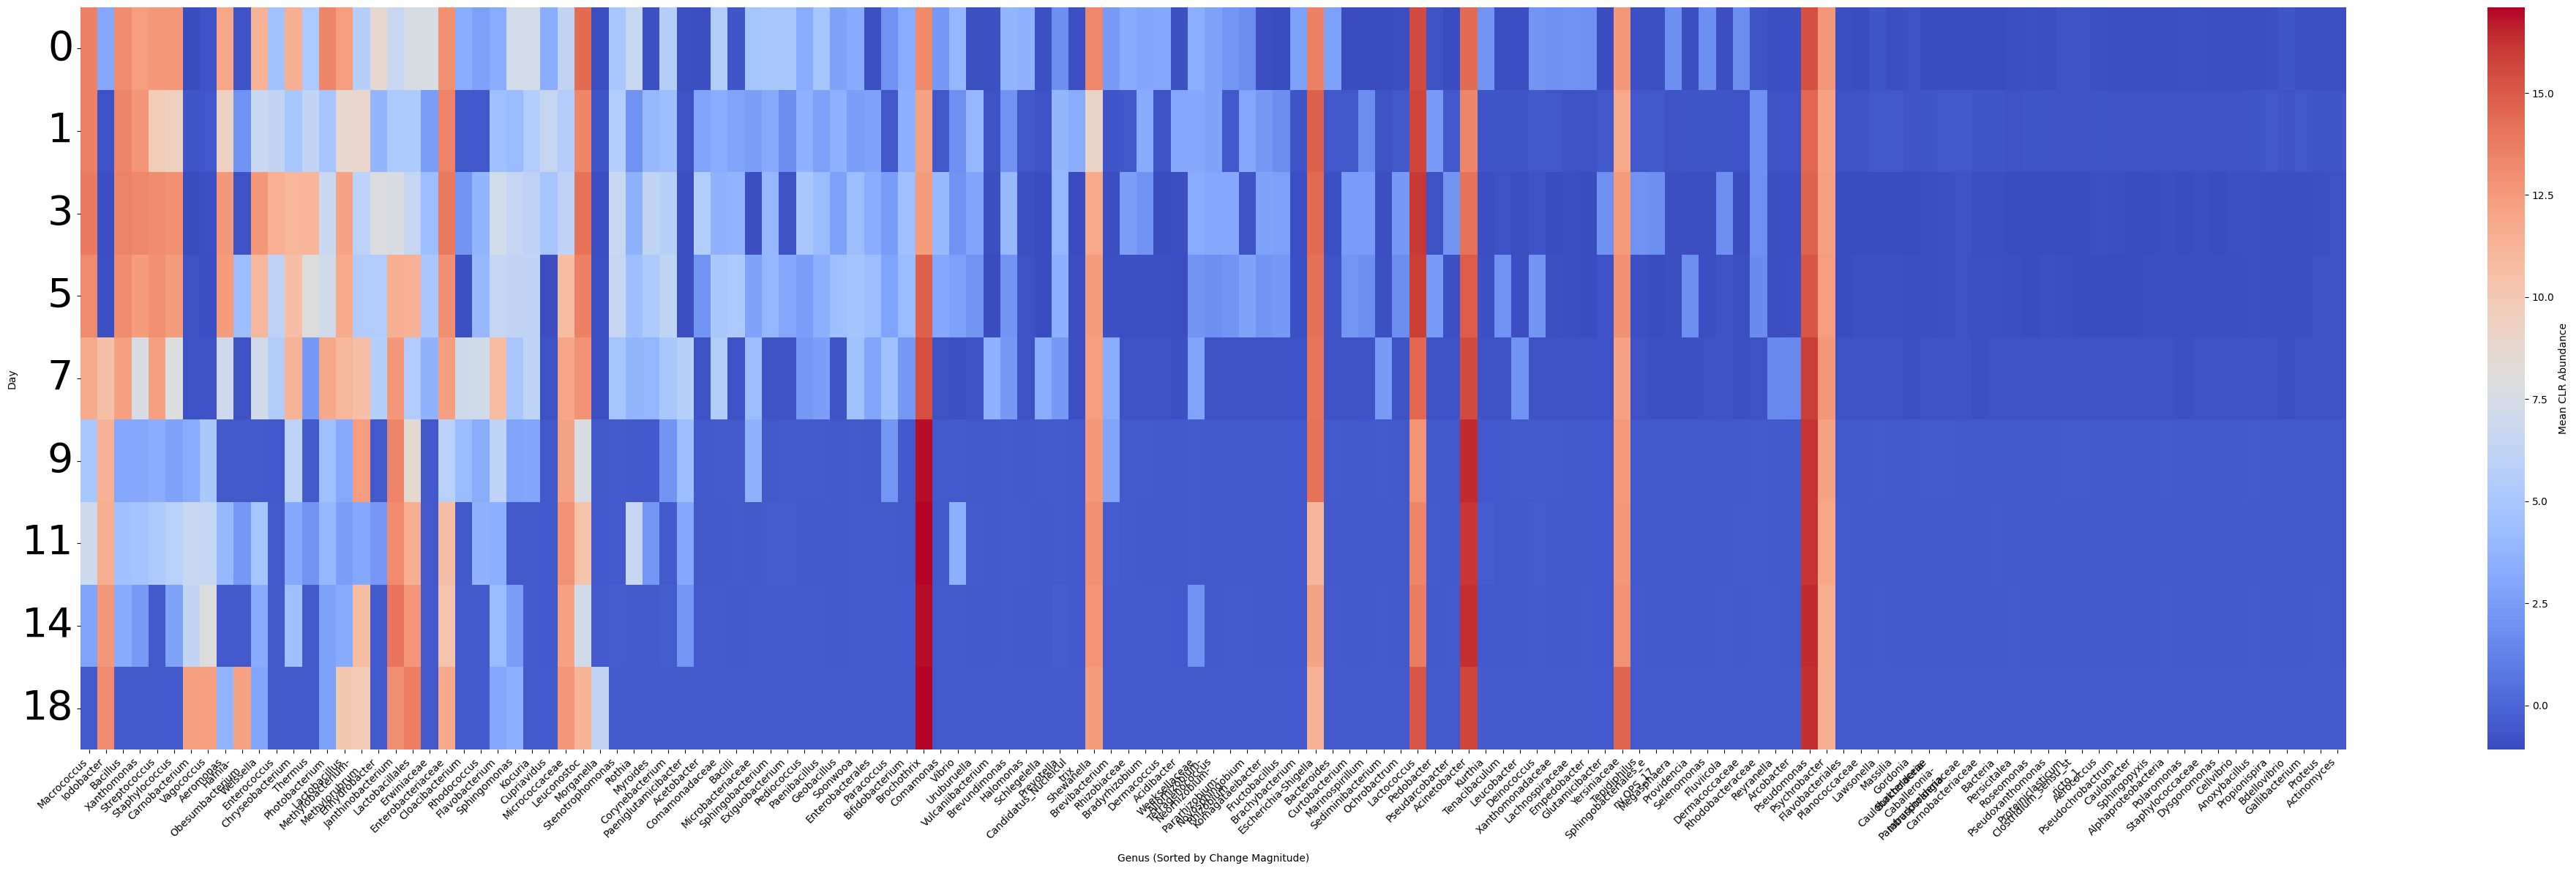

CLR 변환 전 색상 범위: 0.000 ~ 46.636
CLR 변환 후 색상 범위: -1.082 ~ 17.099


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap

# Genus level만 출력
level_name = 'Genus'
sig_data = anova_results[level_name]['significant_data']
if sig_data is None or sig_data.empty:
    print(f"[{level_name}] No significant features by ANOVA, skipped.")
else:
    sig_data = sig_data.copy()
    sig_data['Day'] = sig_data['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    feature_cols = [col for col in sig_data.columns if col not in ['Description', 'Day']]

    # 변화율(최대-최소) 기준으로 feature 정렬
    day_mean_df = sig_data.groupby('Day')[feature_cols].mean()
    feature_changes = (day_mean_df.max() - day_mean_df.min()).abs()
    sorted_features = feature_changes.sort_values(ascending=False).index.tolist()

    # g__ 접두사 제거 및 줄바꿈
    def clean_name(name):
        base = name.replace('g__', '')
        if '(' in base:
            base = base.split('(')[0].strip()
        return '\n'.join(textwrap.wrap(base, width=20))
    sorted_short_names = [clean_name(col) for col in sorted_features]

    fig_width = max(40, 0.22 * len(sorted_features))
    fig_height = max(12, 0.5 * len(day_mean_df))

    # CLR 변환 전 abundance 히트맵을 위한 데이터 가져오기
    genus_orig = None
    for lvl, df in clr_ready_taxonomic_levels:
        if lvl == 'Genus':
            genus_orig = df.copy()
            break

    if genus_orig is not None:
        genus_orig['Day'] = genus_orig['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
        orig_mean = genus_orig.groupby('Day')[sorted_features].mean()

        # CLR 변환 전용 색상 범위
        orig_vmin = orig_mean.min().min()
        orig_vmax = orig_mean.max().max()

        # CLR 변환 후용 색상 범위
        clr_vmin = day_mean_df[sorted_features].min().min()
        clr_vmax = day_mean_df[sorted_features].max().max()

        # CLR 변환 전 히트맵
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(orig_mean, cmap='coolwarm', cbar_kws={'label': 'Mean Abundance'}, 
                   xticklabels=sorted_short_names, vmin=orig_vmin, vmax=orig_vmax)

        plt.xlabel("Genus (Sorted by Change Magnitude)")
        plt.ylabel("Day")
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=40)
        plt.tight_layout()
        plt.show()

        # CLR 변환 후 히트맵 (독립적인 색상 범위)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(day_mean_df[sorted_features], cmap='coolwarm', annot=False, 
                   cbar_kws={'label': 'Mean CLR Abundance'}, xticklabels=sorted_short_names, 
                   vmin=clr_vmin, vmax=clr_vmax)

        plt.xlabel("Genus (Sorted by Change Magnitude)")
        plt.ylabel("Day")
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=40)
        plt.tight_layout()
        plt.show()

        print(f"CLR 변환 전 색상 범위: {orig_vmin:.3f} ~ {orig_vmax:.3f}")
        print(f"CLR 변환 후 색상 범위: {clr_vmin:.3f} ~ {clr_vmax:.3f}")

In [ ]:
%matplotlib inline

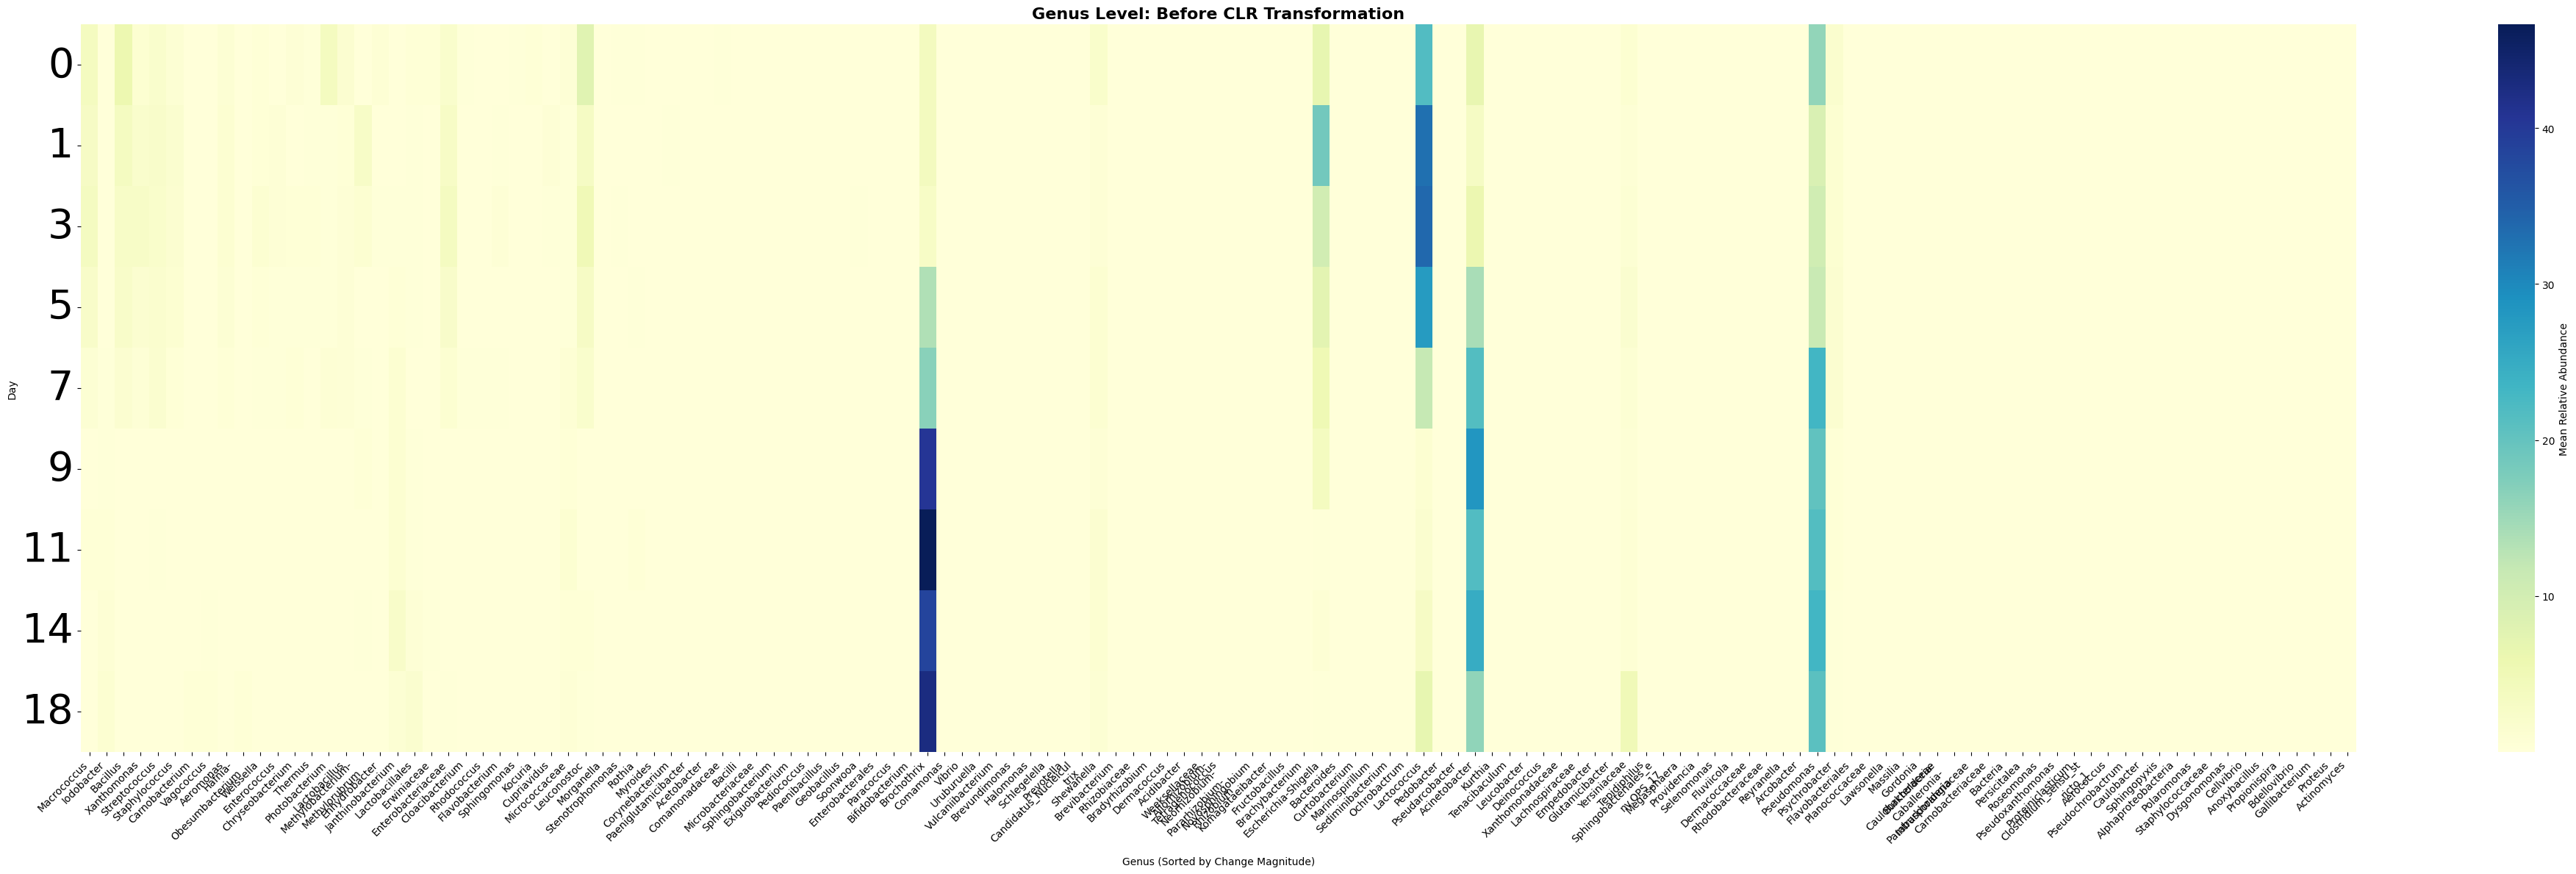

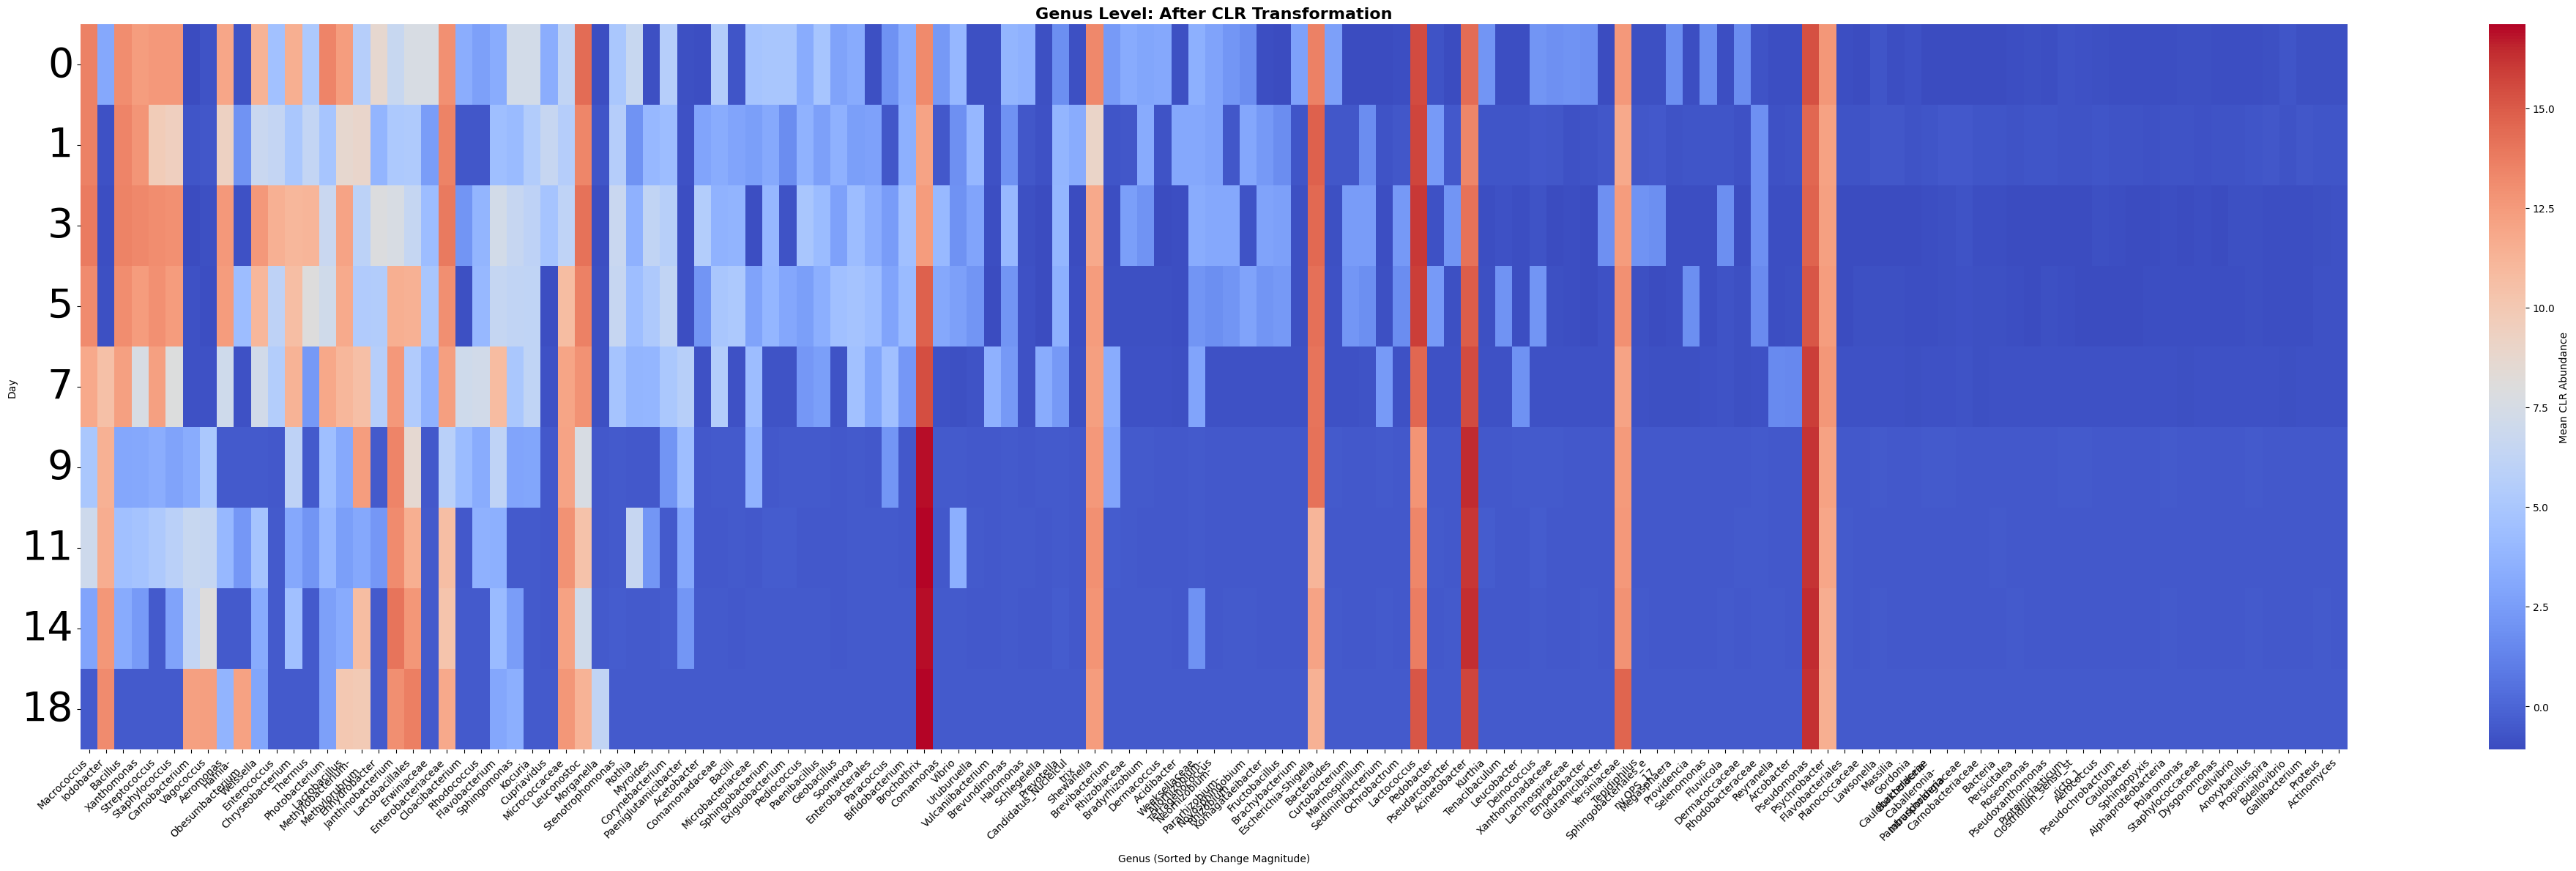

CLR 변환 전 데이터 범위: 0.000 ~ 46.636
CLR 변환 후 데이터 범위: -1.082 ~ 17.099


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap

# Genus level 데이터 추출
genus_orig = None
genus_clr = None

for level_name, df in clr_ready_taxonomic_levels:
    if level_name == 'Genus':
        genus_orig = df.copy()
        break

for level_name, df in clr_transformed_taxonomic_levels:
    if level_name == 'Genus':
        genus_clr = df.copy()
        break

if genus_orig is None or genus_clr is None:
    print("Genus level 데이터가 없습니다.")
else:
    genus_orig['Day'] = genus_orig['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    genus_clr['Day'] = genus_clr['Description'].str.extract(r'A(\d+)', expand=False).astype(int)

    feature_cols = [col for col in genus_orig.columns if col.startswith('g__')]
    def clean_name(name):
        base = name.replace('g__', '')
        if '(' in base:
            base = base.split('(')[0].strip()
        return '\n'.join(textwrap.wrap(base, width=20))
    short_names = [clean_name(col) for col in feature_cols]

    orig_mean = genus_orig.groupby('Day')[feature_cols].mean()
    clr_mean = genus_clr.groupby('Day')[feature_cols].mean()

    fig_width = max(10, 0.22 * len(feature_cols))
    fig_height = max(6, 0.5 * len(orig_mean))

    # CLR 변환 전
    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(orig_mean, cmap='YlGnBu', cbar_kws={'label': 'Relative Abundance'}, xticklabels=short_names)
    plt.title("Comparison of Abundance Before CLR Transformation", fontsize=16, fontweight='bold')
    plt.xlabel("Genus (wrapped)")
    plt.ylabel("Day")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # CLR 변환 후
    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(clr_mean, cmap='coolwarm', cbar_kws={'label': 'CLR Abundance'}, xticklabels=short_names)
    plt.title("Comparison of Abundance After CLR Transformation", fontsize=16, fontweight='bold')
    plt.xlabel("Genus (wrapped)")
    plt.ylabel("Day")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

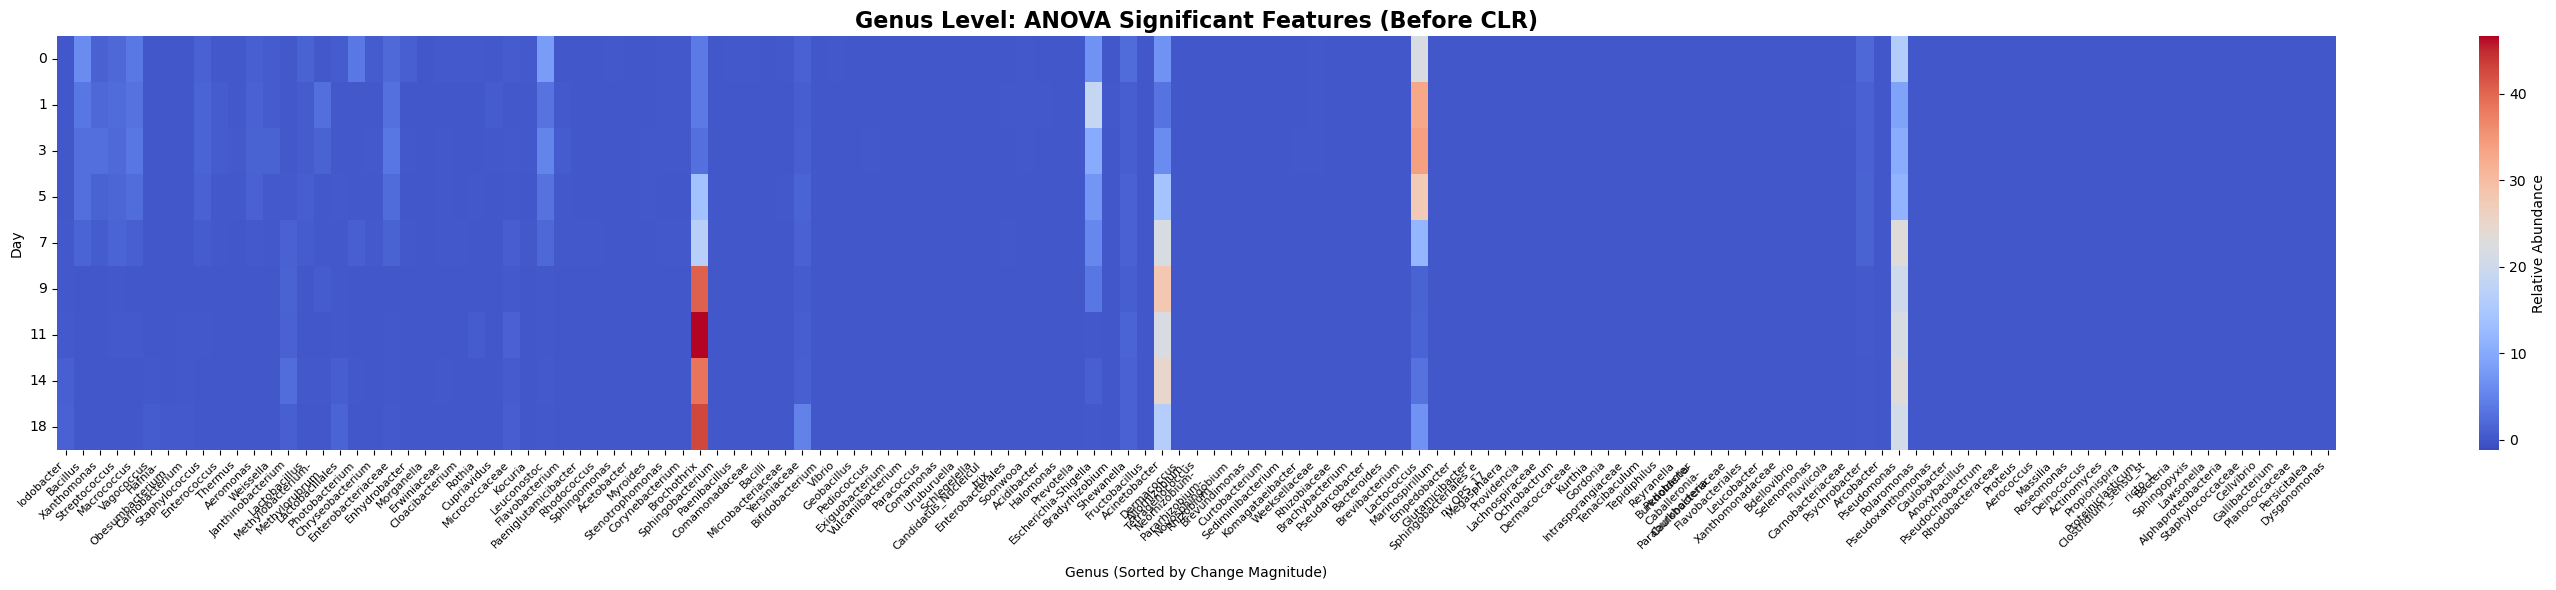

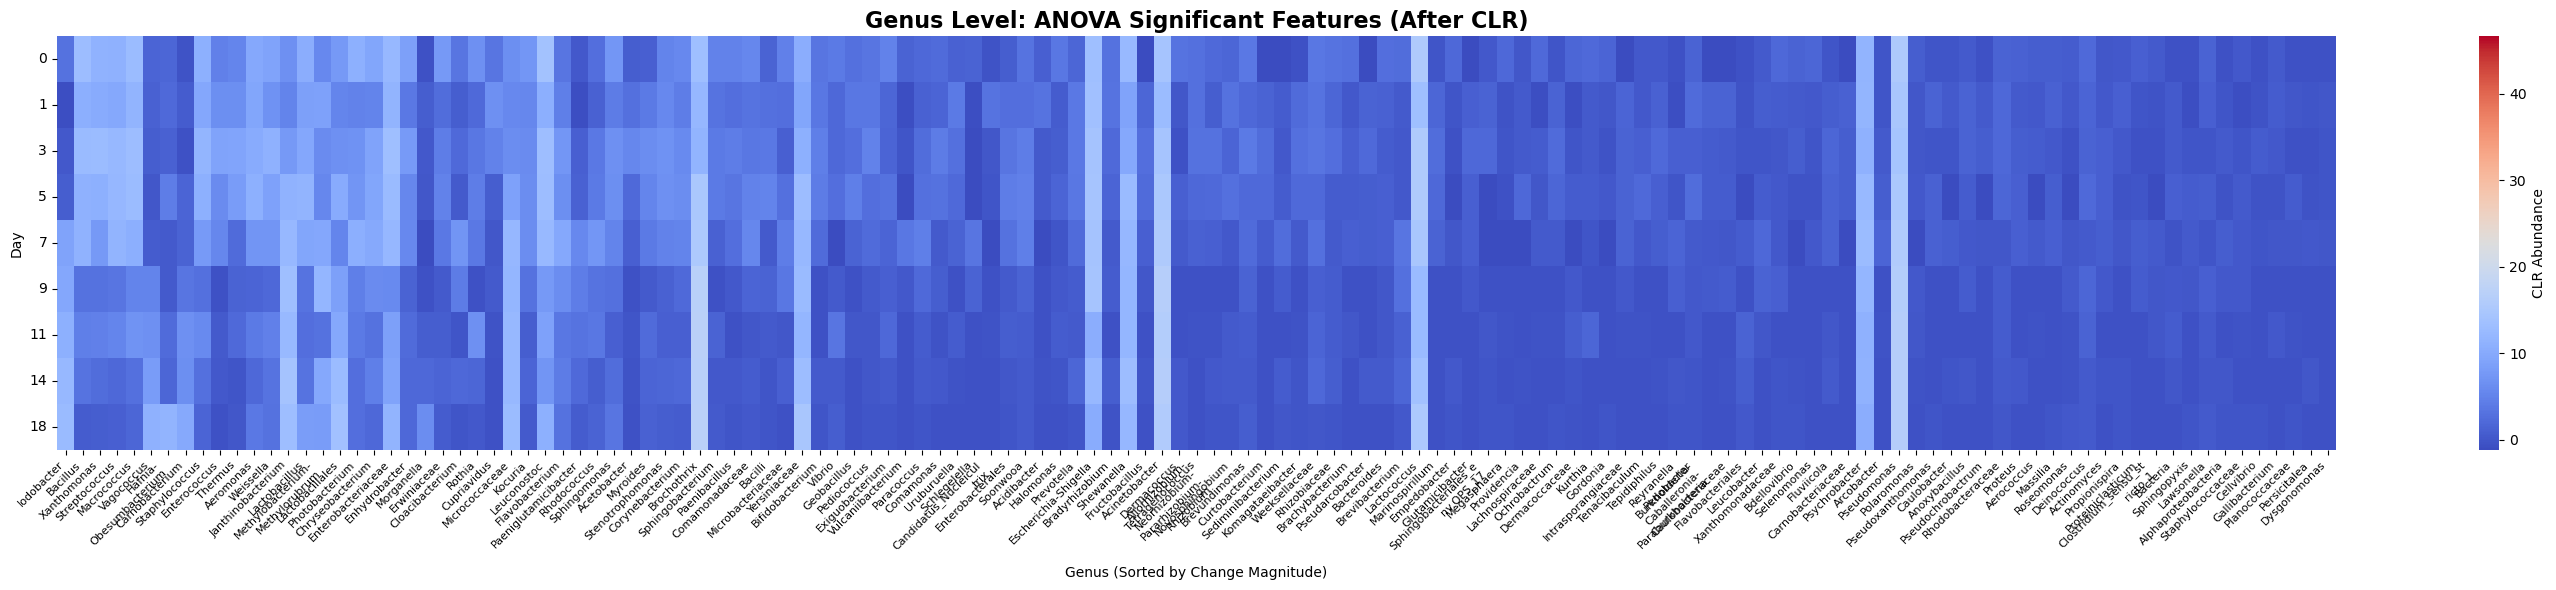

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap

genus_sig_features = anova_results['Genus']['significant_features']
if not genus_sig_features:
    print("Genus level에서 ANOVA 유의 feature가 없습니다.")
else:
    genus_orig = None
    for level_name, df in clr_ready_taxonomic_levels:
        if level_name == 'Genus':
            genus_orig = df.copy()
            break

    genus_clr = None
    for level_name, df in clr_transformed_taxonomic_levels:
        if level_name == 'Genus':
            genus_clr = df.copy()
            break

    if genus_orig is None or genus_clr is None:
        print("Genus level 데이터가 없습니다.")
    else:
        genus_orig['Day'] = genus_orig['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
        genus_clr['Day'] = genus_clr['Description'].str.extract(r'A(\d+)', expand=False).astype(int)

        # feature 이름 정리
        def clean_name(name):
            base = name.replace('g__', '')
            if '(' in base:
                base = base.split('(')[0].strip()
            return '\n'.join(textwrap.wrap(base, width=20))
        short_names = [clean_name(col) for col in genus_sig_features]

        # Day별 평균값
        orig_mean = genus_orig.groupby('Day')[genus_sig_features].mean()
        clr_mean = genus_clr.groupby('Day')[genus_sig_features].mean()

        # 변화량 기준 feature 정렬
        feature_changes = (clr_mean.max() - clr_mean.min()).abs()
        sorted_features = feature_changes.sort_values(ascending=False).index.tolist()
        sorted_short_names = [clean_name(col) for col in sorted_features]

        fig_width = max(10, 0.22 * len(sorted_features))
        fig_height = max(6, 0.5 * len(orig_mean))

        # 색상 범위 맞추기
        vmin = min(orig_mean[sorted_features].min().min(), clr_mean[sorted_features].min().min())
        vmax = max(orig_mean[sorted_features].max().max(), clr_mean[sorted_features].max().max())

        # 변환 전
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(orig_mean[sorted_features], cmap='coolwarm', cbar_kws={'label': 'Relative Abundance'}, xticklabels=sorted_short_names, vmin=vmin, vmax=vmax)
        plt.title("Genus Level: ANOVA Significant Features (Before CLR)", fontsize=16, fontweight='bold')
        plt.xlabel("Genus (Sorted by Change Magnitude)")
        plt.ylabel("Day")
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # 변환 후
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(clr_mean[sorted_features], cmap='coolwarm', cbar_kws={'label': 'CLR Abundance'}, xticklabels=sorted_short_names, vmin=vmin, vmax=vmax)
        plt.title("Genus Level: ANOVA Significant Features (After CLR)", fontsize=16, fontweight='bold')
        plt.xlabel("Genus (Sorted by Change Magnitude)")
        plt.ylabel("Day")
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()